# Passos Mágicos — análise e previsão de defasagem
Dados PEDE de 2022–2024. Objetivo: entender a evolução dos alunos e antecipar novos casos de defasagem.

**Execução:** abra este notebook e execute as células em ordem. Localmente, use o ambiente de `requirements.txt`. No Colab, envie o ZIP completo quando solicitado; o notebook instala as dependências e extrai os arquivos na sessão. As quatro pastas são `data/`, `models/`, `notebooks/` e `outputs/`.

**Leitura dos resultados:** as análises usam o recorte escolar de fases 0–7. A previsão usa alunos sem defasagem, nas fases 0–6. O ano de 2024 já foi examinado em revisões anteriores: a avaliação final é exploratória.

In [1]:
from pathlib import Path
import sys
import zipfile

EM_COLAB = 'google.colab' in sys.modules
if EM_COLAB:
    raiz_colab = Path('/content/passos_magicos_consolidado')
    if not (raiz_colab / 'data/base_pede.xlsx').exists():
        from google.colab import files
        enviados = files.upload()
        pacote = next((Path(n) for n in enviados if n.endswith('.zip')), None)
        if pacote is None:
            raise FileNotFoundError('Envie o ZIP completo do projeto.')
        with zipfile.ZipFile(pacote) as arquivo:
            for nome in arquivo.namelist():
                destino = (Path('/content') / nome).resolve()
                if Path('/content').resolve() not in destino.parents:
                    raise ValueError('O ZIP contém um caminho inválido.')
            arquivo.extractall('/content')
    ROOT = raiz_colab
    get_ipython().run_line_magic('pip', f'install -q -r {ROOT / "requirements.txt"}')
else:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'data/base_pede.xlsx').exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Abra o notebook dentro da pasta completa do projeto.')
DATA, MODELS, OUTPUTS = [ROOT / p for p in ['data', 'models', 'outputs']]
for pasta in [DATA, MODELS, OUTPUTS]:
    pasta.mkdir(exist_ok=True)
print('Pasta do projeto:', ROOT)

Pasta do projeto: /workspace/scratch/5f0c88d9eb3e/output/dashboard_claro/passos_magicos_consolidado


## 1. Preparação e qualidade
Uma linha por aluno e ano. RA serve apenas para acompanhar o mesmo aluno. Ausências e erros de planilha permanecem ausentes; não viram zero. Os valores originais são preservados. O IPP não foi fornecido em 2022.

In [2]:
from datetime import datetime
import hashlib
import json
import platform
import re
import pickle
import numpy as np
import pandas as pd
import openpyxl
from openpyxl.utils.datetime import to_excel
from IPython.display import display, Image, Markdown

CAMINHO_BASE = DATA / 'base_pede.xlsx'
hash_original = hashlib.sha256(CAMINHO_BASE.read_bytes()).hexdigest()
if hash_original != 'c5f50d68f9e065bbe404bdd2677b0c7c1465ac1a20dc3a90552f7891e7d96128':
    raise ValueError('A fonte mudou. Revise os resultados antes de continuar.')
brutas = pd.read_excel(CAMINHO_BASE, sheet_name=None, engine='openpyxl')
assert {'PEDE2022', 'PEDE2023', 'PEDE2024'}.issubset(brutas)
def ler_fase(valor):
    texto = str(valor).strip().upper()
    if texto.startswith('ALFA'):
        return 0
    padrao = re.match(r'^(?:FASE\s*)?(\d+)', texto)
    if padrao is None:
        raise ValueError(f'Fase não reconhecida: {valor}')
    return int(padrao.group(1))

def ler_idade(valor):
    if isinstance(valor, (datetime, pd.Timestamp)):
        return to_excel(valor)
    return pd.to_numeric(valor, errors='raise')

def numerica(coluna):
    return pd.to_numeric(coluna, errors='raise')

indicadores = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv']
quadros = []
for ano in [2022, 2023, 2024]:
    original = brutas[f'PEDE{ano}']
    df = pd.DataFrame(index=original.index)
    df['ra'] = original['RA'].astype('string').str.strip()
    df['ano'] = ano
    df['fase_original'] = original['Fase'].astype('string')
    df['fase'] = original['Fase'].map(ler_fase)
    df['fase_ideal_original'] = original['Fase ideal' if ano == 2022 else 'Fase Ideal'].astype('string')
    df['fase_ideal'] = df['fase_ideal_original'].map(ler_fase)
    origem_idade = original['Idade 22' if ano == 2022 else 'Idade']
    df['idade'] = origem_idade.map(ler_idade)
    df['flag_idade_formato_excel'] = origem_idade.map(lambda x: isinstance(x, (datetime, pd.Timestamp)))
    if ano == 2022:
        df['ano_nascimento'] = numerica(original['Ano nasc'])
    else:
        nascimento = pd.to_datetime(original['Data de Nasc'], format='mixed', dayfirst=True, errors='raise')
        df['ano_nascimento'] = nascimento.dt.year
    df['genero'] = original['Gênero'].replace({'Menina': 'Feminino', 'Menino': 'Masculino'})
    df['ano_ingresso'] = numerica(original['Ano ingresso'])
    df['tipo_instituicao'] = original['Instituição de ensino'].astype('string').str.strip()
    for indicador in indicadores:
        coluna = indicador.upper()
        df[indicador] = numerica(original[coluna]) if coluna in original else np.nan
    df['flag_ipp_ausencia_estrutural'] = ano == 2022
    notas = ['Matem', 'Portug', 'Inglês'] if ano == 2022 else ['Mat', 'Por', 'Ing']
    for destino, origem in zip(['nota_matematica', 'nota_portugues', 'nota_ingles'], notas):
        df[destino] = numerica(original[origem])
    df['quantidade_avaliacoes'] = numerica(original['Nº Av'])
    avaliadores = [c for c in original if c.startswith('Avaliador')]
    df['avaliadores_preenchidos'] = original[avaliadores].notna().sum(axis=1)
    df['defasagem'] = numerica(original['Defas' if ano == 2022 else 'Defasagem'])
    df['defasagem_calculada'] = df['fase'] - df['fase_ideal']
    df['classe_defasagem'] = np.select([df.defasagem.ge(0), df.defasagem.ge(-2)], ['Em fase', 'Moderada'], default='Severa')
    coluna_inde = 'INDE 22' if ano == 2022 else f'INDE {ano}'
    df['inde_original'] = original[coluna_inde].astype('string')
    df['inde'] = pd.to_numeric(original[coluna_inde], errors='coerce')
    df['motivo_inde_ausente'] = np.select(
        [original[coluna_inde].isna(), original[coluna_inde].notna() & df.inde.isna()],
        ['celula_vazia', 'marcador_textual'], default='nao_ausente')
    coluna_pedra = 'Pedra 22' if ano == 2022 else f'Pedra {ano}'
    df['pedra_original'] = original[coluna_pedra].astype('string')
    df['pedra'] = df['pedra_original'].replace({'Agata': 'Ágata', 'INCLUIR': pd.NA})
    permitidas = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    if not df.loc[df.pedra.notna(), 'pedra'].isin(permitidas).all():
        raise ValueError('Pedra não reconhecida: revisar antes de continuar.')
    quadros.append(df)
alunos_ano = pd.concat(quadros, ignore_index=True).sort_values(['ra', 'ano']).reset_index(drop=True)
print(alunos_ano.groupby('ano').agg(registros=('ra', 'size'), alunos=('ra', 'nunique'), inde_preenchido=('inde', 'count')).to_string())

      registros  alunos  inde_preenchido
ano                                     
2022        860     860              860
2023       1014    1014              931
2024       1156    1156             1054


In [3]:
alunos_ano['flag_defasagem_inconsistente'] = alunos_ano.defasagem.ne(alunos_ano.defasagem_calculada)
alunos_ano['flag_iaa_zero'] = alunos_ano.iaa.eq(0)
alunos_ano['flag_ieg_zero'] = alunos_ano.ieg.eq(0)
alunos_ano['flag_ieg_zero_ida_ausente'] = alunos_ano.ieg.eq(0) & alunos_ano.ida.isna()
alunos_ano['flag_ingles_ausente_fase_0_2'] = alunos_ano.fase.between(0, 2) & alunos_ano.nota_ingles.isna()
alunos_ano['flag_quantidade_avaliacoes_divergente'] = alunos_ano.quantidade_avaliacoes.notna() & alunos_ano.quantidade_avaliacoes.ne(alunos_ano.avaliadores_preenchidos)
for campo in ['ano_nascimento', 'ano_ingresso', 'genero']:
    alunos_ano['flag_conflito_' + campo] = alunos_ano.groupby('ra')[campo].transform('nunique').gt(1)
for indicador in indicadores:
    alunos_ano['flag_' + indicador + '_fora_escala'] = alunos_ano[indicador].lt(0) | alunos_ano[indicador].gt(10)
flags = [c for c in alunos_ano if c.startswith('flag_')]
alertas = alunos_ano[['ra', 'ano'] + flags].melt(id_vars=['ra', 'ano'], var_name='sinalizador', value_name='presente')
alertas = alertas[alertas.presente].drop(columns='presente').reset_index(drop=True)
resumo_alertas = alertas.groupby(['ano', 'sinalizador']).size().rename('registros').reset_index()
display(alunos_ano.groupby('ano')[indicadores].agg(lambda s: s.isna().sum()).rename_axis('Ano'))
print('Inconsistências de defasagem:', int(alunos_ano.flag_defasagem_inconsistente.sum()))

Inconsistências de defasagem: 2


,ian,ida,ieg,iaa,ips,ipp,ipv
Ano,,,,,,,
2022,0,0,0,0,0,860,0
2023,0,77,76,63,69,76,76
2024,0,101,0,102,102,102,102


## 2. Acompanhamento e alvo futuro
O painel fixo acompanha quem aparece nos três anos. A previsão usa pares consecutivos, sem exigir presença no terceiro ano.

**Alvo:** defasagem negativa no ano seguinte, entre alunos atualmente sem defasagem e nas fases 0–6. O desfecho precisa estar observado em fase 0–7. Ausentes no ano seguinte não são classificados como “sem risco”. Desenvolvimento: indicadores de 2022 e desfecho de 2023. Avaliação posterior: indicadores de 2023 e desfecho de 2024.

In [4]:
ids_tres_anos = set(alunos_ano.groupby('ra').ano.nunique().loc[lambda s: s.eq(3)].index)
painel_tres_anos = alunos_ano[alunos_ano.ra.isin(ids_tres_anos)].copy()
campos_transicao = ['ra', 'fase', 'idade', 'defasagem', 'classe_defasagem', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde', 'pedra', 'flag_defasagem_inconsistente']
transicoes_lista = []
for ano in [2022, 2023]:
    inicio = alunos_ano[alunos_ano.ano.eq(ano)][campos_transicao]
    fim = alunos_ano[alunos_ano.ano.eq(ano + 1)][campos_transicao]
    par = inicio.merge(fim, on='ra', suffixes=('_inicio', '_fim'), validate='one_to_one')
    par.insert(1, 'ano_inicio', ano)
    par.insert(2, 'ano_fim', ano + 1)
    par['presente_tres_anos'] = par.ra.isin(ids_tres_anos)
    par['fases_0_7_ambos'] = par.fase_inicio.between(0, 7) & par.fase_fim.between(0, 7)
    for indicador in ['defasagem', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']:
        par['delta_' + indicador] = par[indicador + '_fim'] - par[indicador + '_inicio']
    transicoes_lista.append(par)
transicoes = pd.concat(transicoes_lista, ignore_index=True)
print('Painel fixo:', len(ids_tres_anos), 'alunos;', len(painel_tres_anos), 'registros')
print('Transições por origem:', transicoes.ano_inicio.value_counts().sort_index().to_dict())

Painel fixo: 468 alunos; 1404 registros
Transições por origem: {2022: 600, 2023: 765}


In [5]:
FEATURES_PREPARACAO = ['ida', 'ieg', 'ips', 'ipv', 'fase', 'idade']
coortes = {}
fluxos = []
comparacao_coortes = []
auditoria_modelo = []
for ano in [2022, 2023]:
    inicio = alunos_ano[alunos_ano.ano.eq(ano)]
    elegiveis = inicio[inicio.fase.between(0, 6) & inicio.defasagem.ge(0)]
    futuro = alunos_ano[alunos_ano.ano.eq(ano + 1)][['ra', 'fase', 'defasagem', 'flag_defasagem_inconsistente']].rename(
        columns={'fase':'fase_futura', 'defasagem':'defasagem_futura', 'flag_defasagem_inconsistente':'flag_defasagem_futura_inconsistente'})
    unidos = elegiveis.merge(futuro, on='ra', how='left', validate='one_to_one', indicator=True)
    sem_futuro = unidos['_merge'].eq('left_only')
    valido = ~sem_futuro & unidos.fase_futura.between(0, 7) & unidos.defasagem_futura.notna()
    observado = unidos[valido].copy()
    if observado.flag_defasagem_inconsistente.any() or observado.flag_defasagem_futura_inconsistente.any():
        raise ValueError('A coorte contém defasagem inconsistente: revisar antes de definir o alvo.')
    observado['alvo'] = observado.defasagem_futura.lt(0).astype(int)
    coortes[ano] = observado[['ra', 'ano'] + FEATURES_PREPARACAO + ['alvo']].copy().sort_values('ra').reset_index(drop=True)
    if coortes[ano][FEATURES_PREPARACAO].isna().any().any():
        raise ValueError('Features obrigatórias ausentes: não imputar silenciosamente nesta preparação.')
    auditoria = observado[['ra', 'ano', 'defasagem', 'fase_futura', 'defasagem_futura', 'alvo']].copy()
    auditoria_modelo.append(auditoria)
    fluxos.append({'ano_origem': ano, 'elegiveis_iniciais': len(elegiveis),
        'sem_seguimento': int(sem_futuro.sum()), 'outros_sem_desfecho_valido': int((~sem_futuro & ~valido).sum()),
        'coorte_final': len(observado), 'positivos': int(observado.alvo.sum()),
        'negativos': int(observado.alvo.eq(0).sum())})
    for nome, grupo in [('pares_consecutivos', observado), ('apenas_tres_anos', observado[observado.ra.isin(ids_tres_anos)])]:
        comparacao_coortes.append({'ano_origem':ano, 'selecao':nome, 'alunos':len(grupo),
            'positivos':int(grupo.alvo.sum()), 'positivos_pct':round(100*grupo.alvo.mean(),2)})
fluxo_modelo = pd.DataFrame(fluxos)
comparacao_coortes = pd.DataFrame(comparacao_coortes)
auditoria_coortes = pd.concat(auditoria_modelo, ignore_index=True)
print(fluxo_modelo.to_string(index=False))
print('\nComparação de seleção de participantes:')
print(comparacao_coortes.to_string(index=False))
print('\nSobreposição de RA entre desenvolvimento e teste:', len(set(coortes[2022].ra) & set(coortes[2023].ra)))
print('IPV > 10 no teste (preservado):', int(coortes[2023].ipv.gt(10).sum()), '; máximo:', coortes[2023].ipv.max())

 ano_origem  elegiveis_iniciais  sem_seguimento  outros_sem_desfecho_valido  coorte_final  positivos  negativos
       2022                 254              68                           0           186         60        126
       2023                 382              86                           0           296         84        212

Comparação de seleção de participantes:
 ano_origem            selecao  alunos  positivos  positivos_pct
       2022 pares_consecutivos     186         60          32.26
       2022   apenas_tres_anos     151         47          31.13
       2023 pares_consecutivos     296         84          28.38
       2023   apenas_tres_anos     169         16           9.47

Sobreposição de RA entre desenvolvimento e teste: 98
IPV > 10 no teste (preservado): 7 ; máximo: 10.01


São 186 alunos e 60 casos no desenvolvimento; 296 alunos e 84 casos na avaliação posterior. Houve 68 e 86 perdas de acompanhamento, respectivamente. Há 98 alunos em ambos os períodos, com avaliações anuais distintas. Exigir presença nos três anos reduziria os grupos para 151 e 169 alunos e mudaria a população avaliada.

In [6]:
assert len(alunos_ano) == sum(len(brutas[f'PEDE{ano}']) for ano in [2022, 2023, 2024])
assert not alunos_ano.duplicated(['ra', 'ano']).any()
assert not alunos_ano.ra.isna().any()
assert painel_tres_anos.groupby('ra').ano.nunique().eq(3).all()
assert len(painel_tres_anos) == 3 * len(ids_tres_anos)
assert not transicoes.duplicated(['ra', 'ano_inicio']).any()
ian_esperado = np.select([alunos_ano.defasagem.ge(0), alunos_ano.defasagem.ge(-2)], [10.0, 5.0], default=2.5)
assert np.array_equal(alunos_ano.ian.to_numpy(), ian_esperado)
for ano in [2022, 2023, 2024]:
    original = brutas[f'PEDE{ano}'].set_index('RA')
    preparado = alunos_ano[alunos_ano.ano.eq(ano)].set_index('ra').loc[original.index]
    for indicador in indicadores:
        if indicador.upper() in original:
            a = original[indicador.upper()].to_numpy(dtype=float)
            b = preparado[indicador].to_numpy(dtype=float)
            assert np.allclose(a, b, equal_nan=True), (ano, indicador)
for ano, coorte in coortes.items():
    assert coorte.columns.tolist() == ['ra', 'ano'] + FEATURES_PREPARACAO + ['alvo']
    assert coorte.ano.eq(ano).all() and not coorte.ra.duplicated().any()
    assert coorte.alvo.isin([0, 1]).all()
    assert coorte.fase.between(0, 6).all()
assert hashlib.sha256(CAMINHO_BASE.read_bytes()).hexdigest() == hash_original
print('Verificações concluídas: dados brutos intactos, indicadores preservados, chaves únicas e features explícitas.')

for ano, nome in [(2022, 'desenvolvimento.csv'), (2023, 'teste_temporal.csv')]:
    coortes[ano].to_csv(DATA / nome, index=False)
# Exportar somente as colunas necessárias à aplicação. A análise completa permanece em memória.
COLUNAS_APP = ['ra', 'ano', 'fase', 'pedra', 'defasagem', 'classe_defasagem', 'ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
alunos_ano[COLUNAS_APP].to_csv(DATA / 'alunos_ano.csv', index=False)

Verificações concluídas: dados brutos intactos, indicadores preservados, chaves únicas e features explícitas.


## 3. Análises de negócio
O recorte escolar tem 860, 951 e 1.054 alunos por ano. O painel fixo reúne 441 alunos; cada indicador usa apenas suas avaliações disponíveis. Fases 8–9 permanecem na fonte, mas não entram na comparação escolar principal. Pedras são categorias do INDE.

As associações usam Spearman. Mudanças de até 0,1 ponto são tratadas como estabilidade descritiva. Nenhuma dessas medidas demonstra causalidade.

In [7]:
import matplotlib.pyplot as plt
import base64
GRAFICOS_NEGOCIO = {str(i): [] for i in range(1,11)}
import scipy
from IPython.display import display, Image

HASH_ANALISADO = 'c5f50d68f9e065bbe404bdd2677b0c7c1465ac1a20dc3a90552f7891e7d96128'
if hash_original != HASH_ANALISADO:
    raise ValueError('A fonte mudou: revalidar números e conclusões antes de usar esta versão da análise.')
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,
    'axes.spines.right':False,'axes.titlesize':13,'figure.dpi':120,'savefig.dpi':160})
CORES = ['#285C76','#D99C38','#A95154','#579E8C','#7F6D9F','#758497','#A9B369']
ANOS = [2022,2023,2024]
CLASSES = ['Em fase','Moderada','Severa']
PEDRAS = ['Quartzo','Ágata','Ametista','Topázio']
ESCOLARES = alunos_ano[alunos_ano.fase.between(0,7)].copy()
ids_escolares_fixos = set(painel_tres_anos.groupby('ra').fase.max().loc[lambda s:s.le(7)].index)
PAINEL_ESCOLAR = painel_tres_anos[painel_tres_anos.ra.isin(ids_escolares_fixos)].copy()
PARES_ESCOLARES = transicoes[transicoes.fases_0_7_ambos].copy()
def tabela(df,nome,mostrar=True):
    if mostrar:display(df.round(4))
    return df

def figura(fig,nome,legenda=''):
    from io import BytesIO
    fig.tight_layout()
    buffer=BytesIO()
    fig.savefig(buffer,format='png',bbox_inches='tight')
    grupo = re.match(r'q(\d+)_',nome)
    if grupo:
        GRAFICOS_NEGOCIO[grupo[1]].append({'png':base64.b64encode(buffer.getvalue()).decode('ascii'),'legenda':legenda})
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
    if legenda: display(Markdown('**Como ler:** '+legenda))

def rho(df,x,y,estrito=False,sem_zero_iaa=False):
    z=df[[x,y]].dropna().copy()
    if estrito:
        # Para deltas, não usar esta opção; seus valores podem ser negativos.
        z=z[z[x].between(0,10)&z[y].between(0,10)]
    if sem_zero_iaa:
        for c in [x,y]:
            if c in ['iaa','iaa_inicio','iaa_fim']:z=z[z[c].gt(0)]
    return {'n':len(z),'rho':z[x].corr(z[y],method='spearman') if len(z)>2 and z[x].nunique()>1 and z[y].nunique()>1 else np.nan}
def painel_completo(indicador):
    return PAINEL_ESCOLAR.pivot(index='ra',columns='ano',values=indicador).reindex(columns=ANOS).dropna()
def classe_delta(serie,tolerancia=.1):
    return np.select([serie.gt(tolerancia+1e-9),serie.lt(-tolerancia-1e-9)],['Melhora','Piora'],default='Estável')
print('Painel original:',len(ids_tres_anos),'alunos. Painel escolar fixo:',len(ids_escolares_fixos),'alunos.')
print('SciPy:',scipy.__version__)

Painel original: 468 alunos. Painel escolar fixo: 441 alunos.
SciPy: 1.13.1


### Pergunta 1
**Pergunta:** Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

**Gráfico:** Defasagem por ano: barras com alunos em fase, com defasagem moderada e severa.

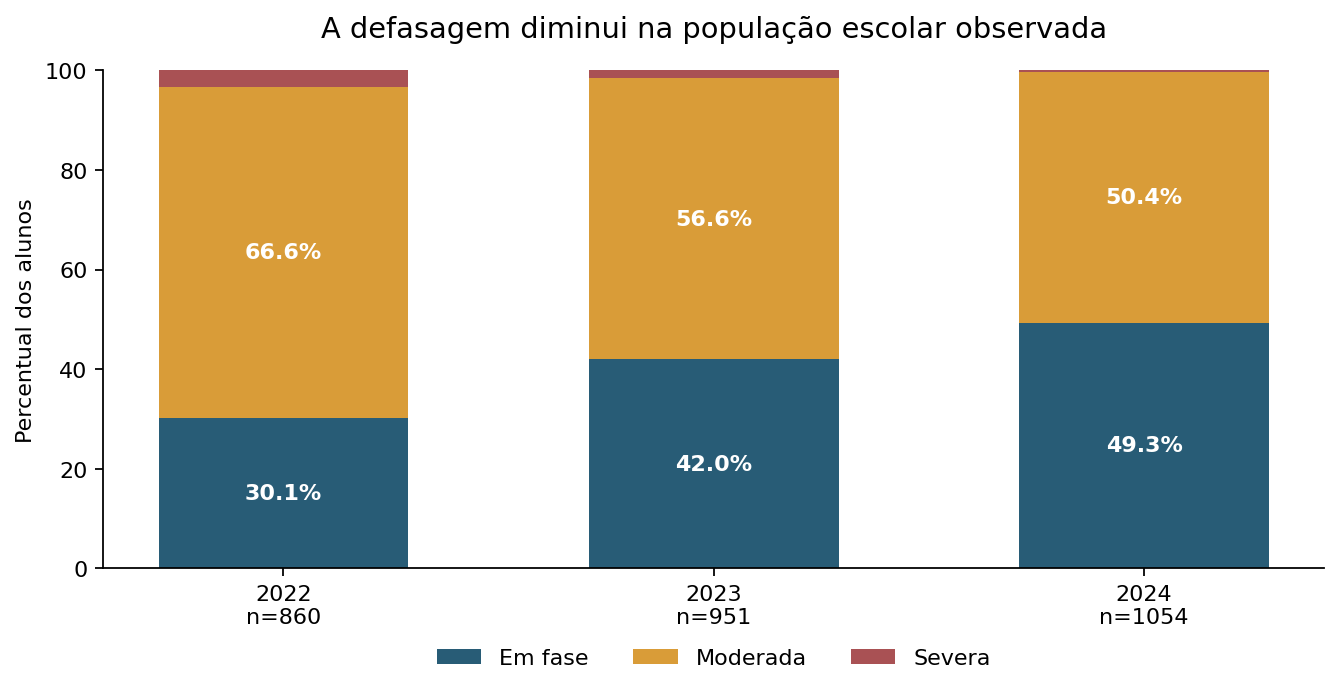

**Como ler:** As cores separam a situação de adequação. Cada barra soma 100% dos alunos escolares daquele ano.

In [8]:
q1_linhas=[]
for nome,base in [('Todos',alunos_ano),('Fases 0–7',ESCOLARES),('Painel escolar fixo',PAINEL_ESCOLAR)]:
    for ano,g in base.groupby('ano'):
        for classe in CLASSES:
            n=int(g.classe_defasagem.eq(classe).sum())
            q1_linhas.append({'populacao':nome,'ano':ano,'classe':classe,'n':n,'total':len(g),'percentual':100*n/len(g)})
q1=pd.DataFrame(q1_linhas)
fig,ax=plt.subplots(figsize=(8.5,4.5));fundo=np.zeros(3)
for classe,cor in zip(CLASSES,CORES):
    valores=q1[(q1.populacao=='Fases 0–7') & (q1.classe==classe)].set_index('ano').loc[ANOS,'percentual'].to_numpy()
    ax.bar([str(x) for x in ANOS],valores,bottom=fundo,label=classe,color=cor,width=.58)
    for i,v in enumerate(valores):
        if v>5:ax.text(i,fundo[i]+v/2,f'{v:.1f}%',ha='center',va='center',color='white',fontweight='bold')
    fundo+=valores
ax.set(ylim=(0,100),ylabel='Percentual dos alunos',xticks=range(3),xticklabels=[f'{ano}\nn={len(ESCOLARES[ESCOLARES.ano.eq(ano)])}' for ano in ANOS])
ax.set_title('A defasagem diminui na população escolar observada',pad=15)
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=3,frameon=False)
figura(fig,'q1_defasagem_anual','As cores separam a situação de adequação. Cada barra soma 100% dos alunos escolares daquele ano.')

**Resposta:** Nas fases 0–7, a defasagem passou de 69,9% (601/860) em 2022 para 58,0% (552/951) em 2023 e 50,7% (534/1.054) em 2024. Os casos severos foram 28, 14 e 3; os moderados, 573, 538 e 531. Entre os mesmos 441 alunos, a proporção caiu de 66,0% para 37,0%. Há avanço na adequação, mas metade do grupo de 2024 ainda demanda acompanhamento. A base permite comparar anos, não meses dentro do ano.

### Pergunta 2
**Pergunta:** O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

**Gráfico:** IDA por ano e por fase de origem: evolução anual e mudança de 2022 a 2024.

,ano,n,media,mediana,q25,q75
0,2022,860,6.0929,6.30,4.800,7.6
1,2023,937,6.6634,6.80,5.700,7.9
2,2024,1054,6.3499,6.75,4.875,8.0


,ano,n,media,mediana
0,2022,435,6.6784,7.0
1,2023,435,6.7687,6.8
2,2024,435,6.2074,6.5


,fase_2022,n,media,mediana
0,0,117,-1.0077,-0.8000
1,1,119,-0.9354,-1.0000
2,2,82,-0.2138,0.0000
3,3,66,0.5768,0.7500
4,4,33,-0.1545,0.1667
5,5,18,0.4935,0.3333


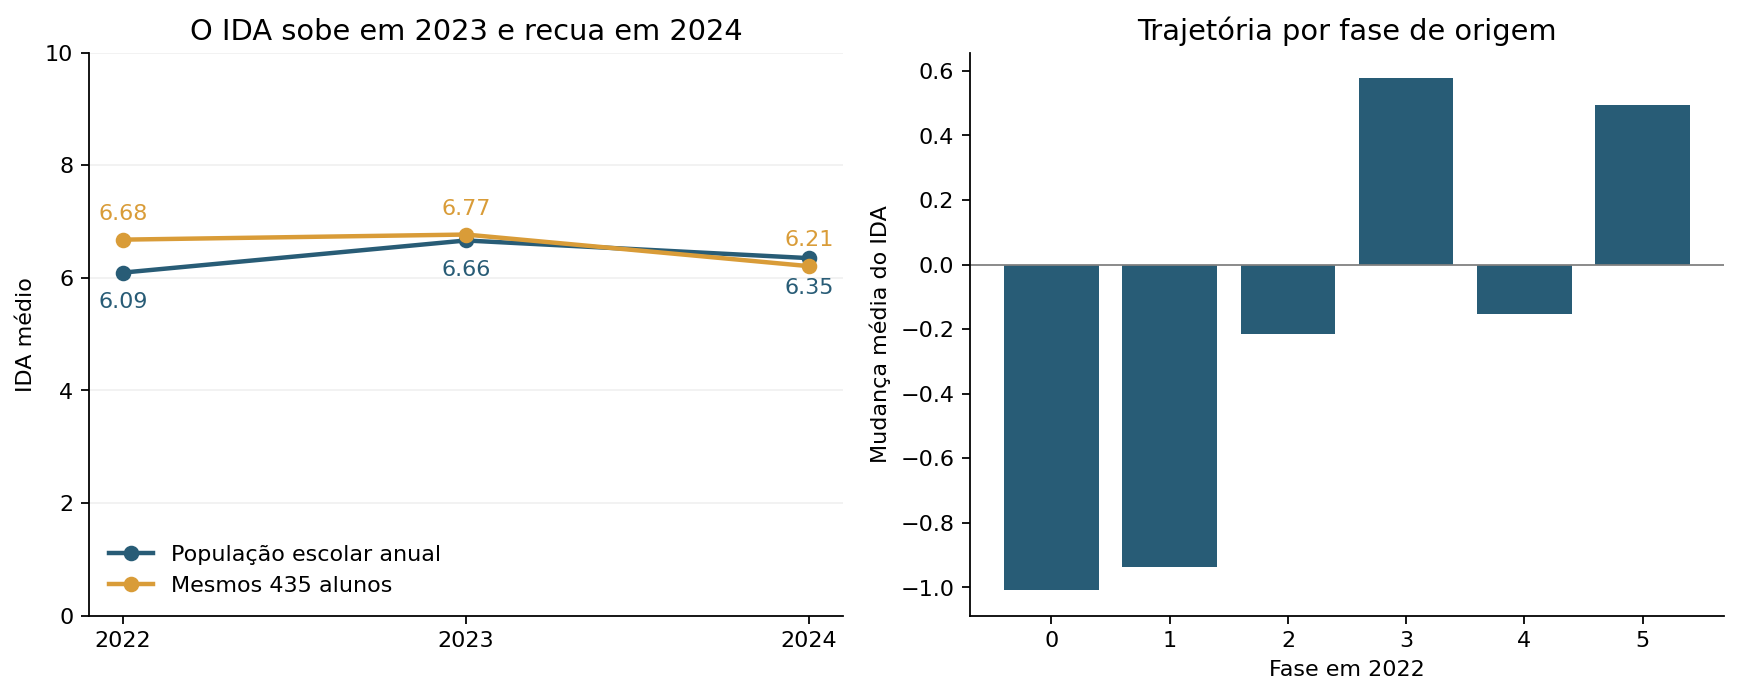

**Como ler:** As linhas comparam médias anuais com as dos mesmos alunos. As barras mostram a mudança por fase de 2022: abaixo de zero significa queda.

In [9]:
q2_anual=ESCOLARES.groupby('ano').ida.agg(n='count',media='mean',mediana='median',q25=lambda s:s.quantile(.25),q75=lambda s:s.quantile(.75)).reset_index()
tabela(q2_anual,'q2_ida_anual')
q2_fase=ESCOLARES.groupby(['ano','fase']).ida.agg(n='count',media='mean',mediana='median').reset_index()
tabela(q2_fase,'q2_ida_por_fase',False)
w_ida=painel_completo('ida')
q2_painel=pd.DataFrame({'ano':ANOS,'n':len(w_ida),'media':w_ida.mean().values,'mediana':w_ida.median().values})
tabela(q2_painel,'q2_ida_painel_completo')
fase_inicial=PAINEL_ESCOLAR[PAINEL_ESCOLAR.ano.eq(2022)].set_index('ra').fase
aux=w_ida.assign(fase_2022=fase_inicial,delta_22_24=w_ida[2024]-w_ida[2022])
q2_delta_fase=aux.groupby('fase_2022').delta_22_24.agg(n='count',media='mean',mediana='median').reset_index()
tabela(q2_delta_fase,'q2_delta_ida_fase_inicial')
fig,axes=plt.subplots(1,2,figsize=(11,4.5));ax=axes[0]
for dados,label,cor in [(q2_anual,'População escolar anual',CORES[0]),(q2_painel,'Mesmos 435 alunos',CORES[1])]:
    ax.plot(dados.ano,dados.media,marker='o',linewidth=2,color=cor,label=label)
    for ano,v in zip(dados.ano,dados.media):ax.annotate(f'{v:.2f}',(ano,v),xytext=(0,9 if label.startswith('Mesmos') else -16),textcoords='offset points',ha='center',color=cor)
ax.set(xticks=ANOS,ylim=(0,10),ylabel='IDA médio',title='O IDA sobe em 2023 e recua em 2024')
ax.legend(frameon=False,loc='lower left');ax.grid(axis='y',alpha=.18)
axes[1].bar(q2_delta_fase.fase_2022.astype(str),q2_delta_fase.media,color=CORES[0])
axes[1].axhline(0,color='gray',linewidth=.8)
axes[1].set(xlabel='Fase em 2022',ylabel='Mudança média do IDA',title='Trajetória por fase de origem')
figura(fig,'q2_ida_anual_painel','As linhas comparam médias anuais com as dos mesmos alunos. As barras mostram a mudança por fase de 2022: abaixo de zero significa queda.')

**Resposta:** O IDA médio foi 6,09 → 6,66 → 6,35. Entre os mesmos 435 alunos com notas nos três anos, foi 6,68 → 6,77 → 6,21. Não há melhora contínua. Quem estava nas fases 0 e 1 em 2022 teve queda média de 1,01 e 0,94 ponto; nas fases 3 e 5, houve aumento de 0,58 e 0,49. Vale investigar as dificuldades e os critérios de avaliação de 2024. As provas podem mudar entre fases.

### Pergunta 3
**Pergunta:** O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

**Gráfico:** Engajamento e resultados: dispersões de IEG com IDA e IPV em 2024; tabela das associações nos três anos.

,ano,par,n,rho
0,2022,IEG–IDA,860,0.5074
1,2022,IEG–IPV,860,0.5403
2,2023,IEG–IDA,937,0.4465
3,2023,IEG–IPV,938,0.4920
4,2024,IEG–IDA,1054,0.5191
5,2024,IEG–IPV,1054,0.5510


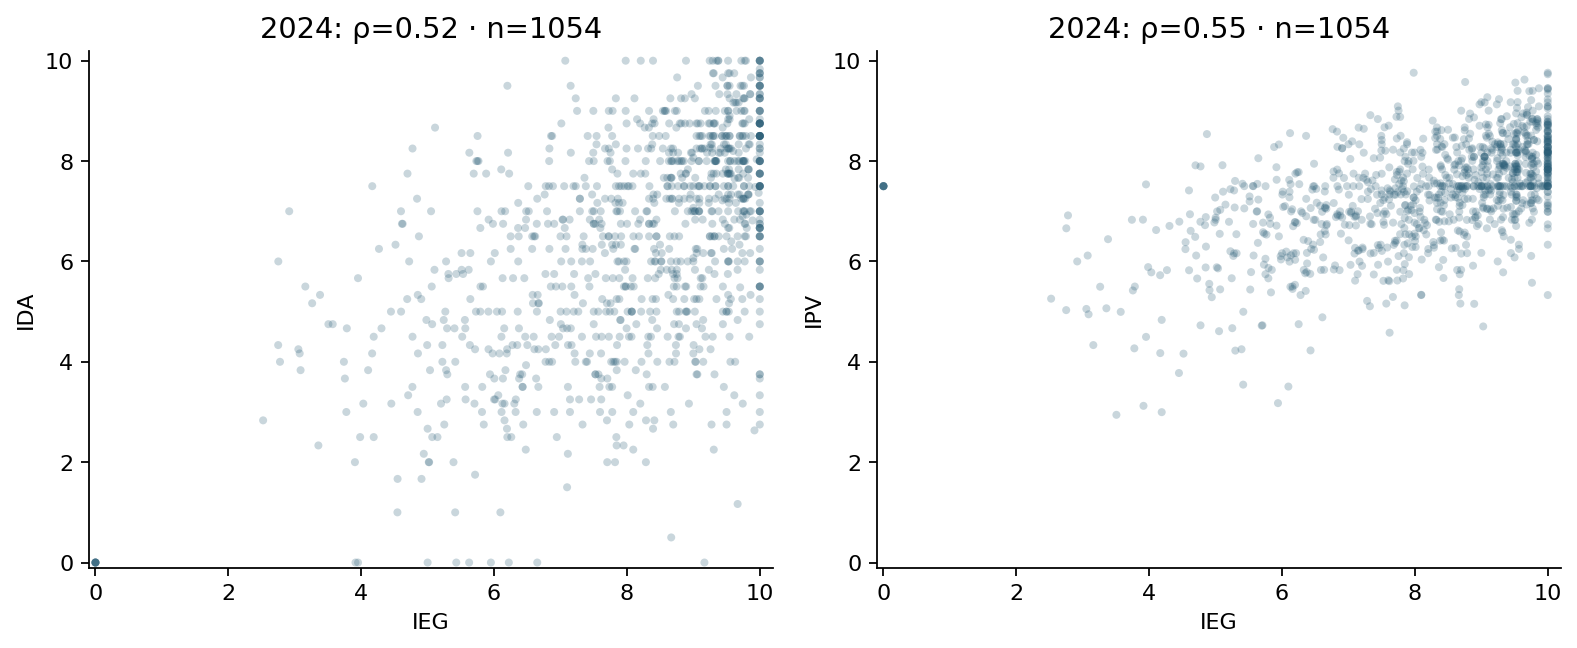

**Como ler:** Cada ponto é um aluno de 2024. À direita, maior engajamento; mais acima, maior desempenho ou ponto de virada.

In [10]:
q3_rows=[];q3_fases=[]
for ano,g in ESCOLARES.groupby('ano'):
    for destino in ['ida','ipv']:
        q3_rows.append({'ano':ano,'par':f'IEG–{destino.upper()}',**rho(g,'ieg',destino)})
        for fase,z in g.groupby('fase'):
            q3_fases.append({'ano':ano,'fase':fase,'par':f'IEG–{destino.upper()}',**rho(z,'ieg',destino)})
q3=tabela(pd.DataFrame(q3_rows),'q3_correlacoes')
tabela(pd.DataFrame(q3_fases),'q3_correlacoes_por_fase',False)
g=ESCOLARES[ESCOLARES.ano.eq(2024)]
fig,axes=plt.subplots(1,2,figsize=(10,4.2))
for ax,y in zip(axes,['ida','ipv']):
    z=g[['ieg',y]].dropna();r=rho(z,'ieg',y)
    ax.scatter(z.ieg,z[y],s=13,alpha=.25,color=CORES[0],edgecolors='none')
    ax.set(xlim=(-.1,10.2),ylim=(-.1,10.2),xlabel='IEG',ylabel=y.upper(),title=f'2024: ρ={r["rho"]:.2f} · n={r["n"]}')
figura(fig,'q3_ieg_desempenho','Cada ponto é um aluno de 2024. À direita, maior engajamento; mais acima, maior desempenho ou ponto de virada.')

**Resposta:** Sim, há associação positiva no mesmo ano: IEG–IDA apresenta correlações de 0,51; 0,45; 0,52, e IEG–IPV de 0,54; 0,49; 0,55. Alunos mais engajados tendem a ter avaliações maiores nessas dimensões. Isso apoia o acompanhamento conjunto, mas não prova que aumentar o engajamento cause melhora ou reduza o risco futuro.

### Pergunta 4
**Pergunta:** As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

**Gráfico:** Autoavaliação e outras avaliações: dispersões de IAA com IDA e IEG; tabela de sensibilidade aos zeros.

,ano,par,analise,n,rho,diferenca_media,diferenca_mediana
0,2022,IAA–IDA,Observados,860,0.1829,2.1815,2.2000
1,2022,IAA–IDA,IAA sem zeros,821,0.1421,2.5033,2.3000
2,2022,IAA–IEG,Observados,860,0.2342,0.3833,0.4000
3,2022,IAA–IEG,IAA sem zeros,821,0.1638,0.6778,0.4000
4,2023,IAA–IDA,Observados,937,0.1269,0.2547,1.2000
5,2023,IAA–IDA,IAA sem zeros,751,0.1083,1.9045,1.8000
6,2023,IAA–IEG,Observados,938,0.1913,-1.7883,-0.5000
7,2023,IAA–IEG,IAA sem zeros,751,0.1311,-0.1470,-0.2000
8,2024,IAA–IDA,Observados,1054,0.1784,2.1937,2.0020
9,2024,IAA–IDA,IAA sem zeros,1034,0.1477,2.3109,2.0020


,ano,n_iaa,zeros_iaa,media_iaa,media_iaa_sem_zeros
0,2022,860,39,8.2744,8.6675
1,2023,951,190,6.9030,8.6265
2,2024,1054,20,8.5436,8.7088


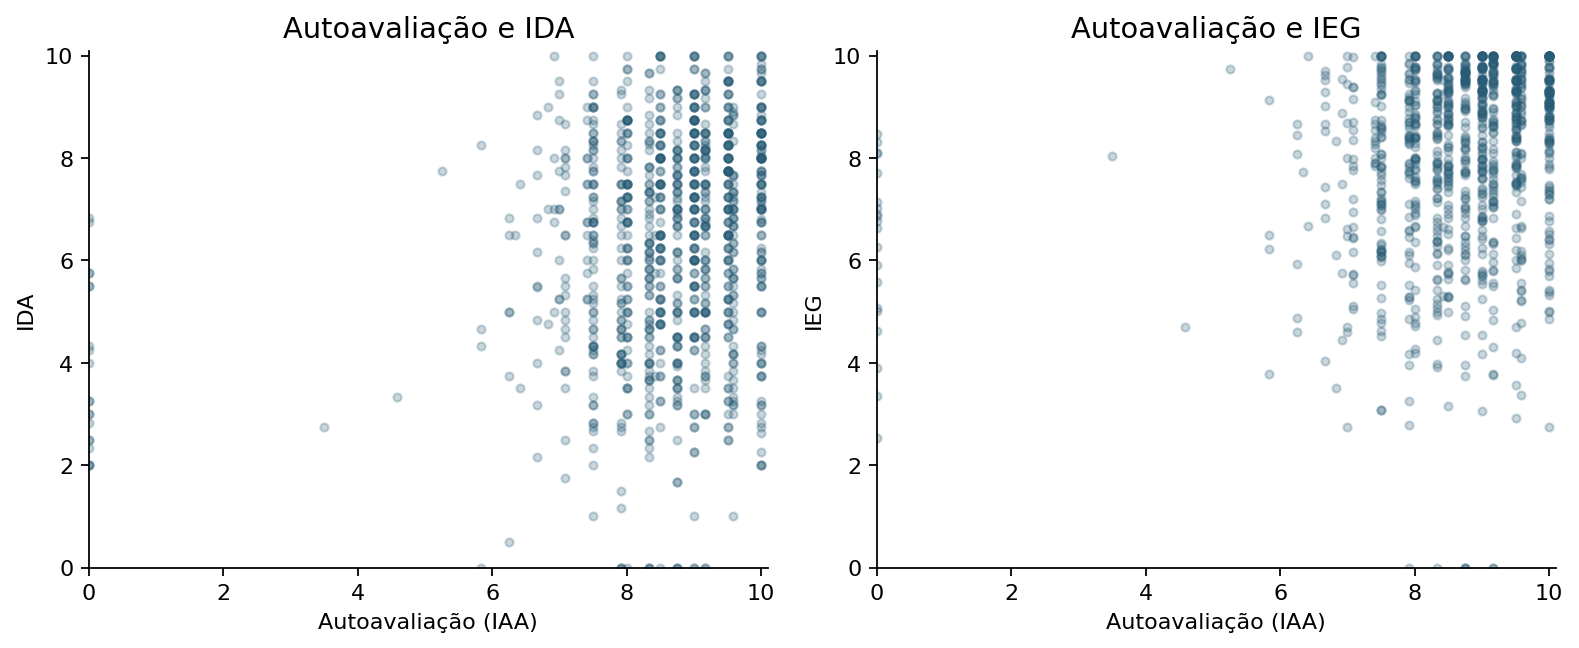

**Como ler:** Cada ponto é um aluno de 2024. À direita, maior autoavaliação; mais acima, maior desempenho ou engajamento.

In [11]:
q4_rows=[];q4_medias=[]
for ano,g in ESCOLARES.groupby('ano'):
    q4_medias.append({'ano':ano,'n_iaa':g.iaa.count(),'zeros_iaa':int(g.iaa.eq(0).sum()),
        'media_iaa':g.iaa.mean(),'media_iaa_sem_zeros':g.loc[g.iaa.gt(0),'iaa'].mean()})
    for destino in ['ida','ieg']:
        for modo in ['Observados','IAA sem zeros']:
            z=g if modo=='Observados' else g[g.iaa.gt(0)]
            pares=z[['iaa',destino]].dropna()
            q4_rows.append({'ano':ano,'par':f'IAA–{destino.upper()}','analise':modo,**rho(pares,'iaa',destino),
                'diferenca_media':(pares.iaa-pares[destino]).mean(),'diferenca_mediana':(pares.iaa-pares[destino]).median()})
q4=tabela(pd.DataFrame(q4_rows),'q4_associacoes_diferencas')
q4_medias=tabela(pd.DataFrame(q4_medias),'q4_sensibilidade_zeros')
fig,axes=plt.subplots(1,2,figsize=(10,4.2))
g=ESCOLARES[ESCOLARES.ano.eq(2024)]
for ax,y in zip(axes,['ida','ieg']):
    pares=g[['iaa',y]].dropna()
    ax.scatter(pares.iaa,pares[y],s=13,alpha=.25,color=CORES[0])
    ax.set(xlabel='Autoavaliação (IAA)',ylabel=y.upper(),xlim=(0,10.1),ylim=(0,10.1),title='Autoavaliação e '+y.upper())
figura(fig,'q4_autoavaliacao','Cada ponto é um aluno de 2024. À direita, maior autoavaliação; mais acima, maior desempenho ou engajamento.')

**Resposta:** A correspondência é fraca: as correlações ficam aproximadamente entre 0,13 e 0,23. Em 2023, há 190 autoavaliações iguais a zero; a média muda de 6,90 para 8,63 quando esses registros são retirados apenas para comparação. IAA traz uma perspectiva complementar, que pode orientar conversas. É necessário esclarecer o significado dos zeros antes de concluir que a autopercepção piorou.

### Pergunta 5
**Pergunta:** Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

**Gráfico:** IPS anterior e quedas: percentual de alunos com queda de IDA ou IEG por faixa de IPS, nas duas transições.

,origem,desfecho,n,rho,quedas_maiores_01,pct_queda_01,pct_qualquer_queda
0,2022,delta_ida,574,0.0287,267,46.5157,49.6516
1,2022,delta_ieg,574,-0.0240,175,30.4878,37.1080
2,2023,delta_ida,678,0.0275,368,54.2773,57.0796
3,2023,delta_ieg,678,0.0337,417,61.5044,66.2242


,origem,desfecho,faixa_ips,ips_min,ips_max,n,quedas,pct_queda
0,2022,ida,"(2.499, 5.6]",2.50,5.60,148,76,51.3514
1,2022,ida,"(5.6, 7.5]",6.30,7.50,395,175,44.3038
2,2022,ida,"(7.5, 9.4]",8.10,9.40,31,16,51.6129
3,2022,ieg,"(2.499, 5.6]",2.50,5.60,148,42,28.3784
4,2022,ieg,"(5.6, 7.5]",6.30,7.50,395,126,31.8987
5,2022,ieg,"(7.5, 9.4]",8.10,9.40,31,7,22.5806
6,2023,ida,"(2.519, 5.0]",2.52,5.00,349,187,53.5817
7,2023,ida,"(5.0, 7.52]",5.02,7.52,322,179,55.5901
8,2023,ida,"(7.52, 9.38]",8.13,9.38,7,2,28.5714
9,2023,ieg,"(2.519, 5.0]",2.52,5.00,349,220,63.0372


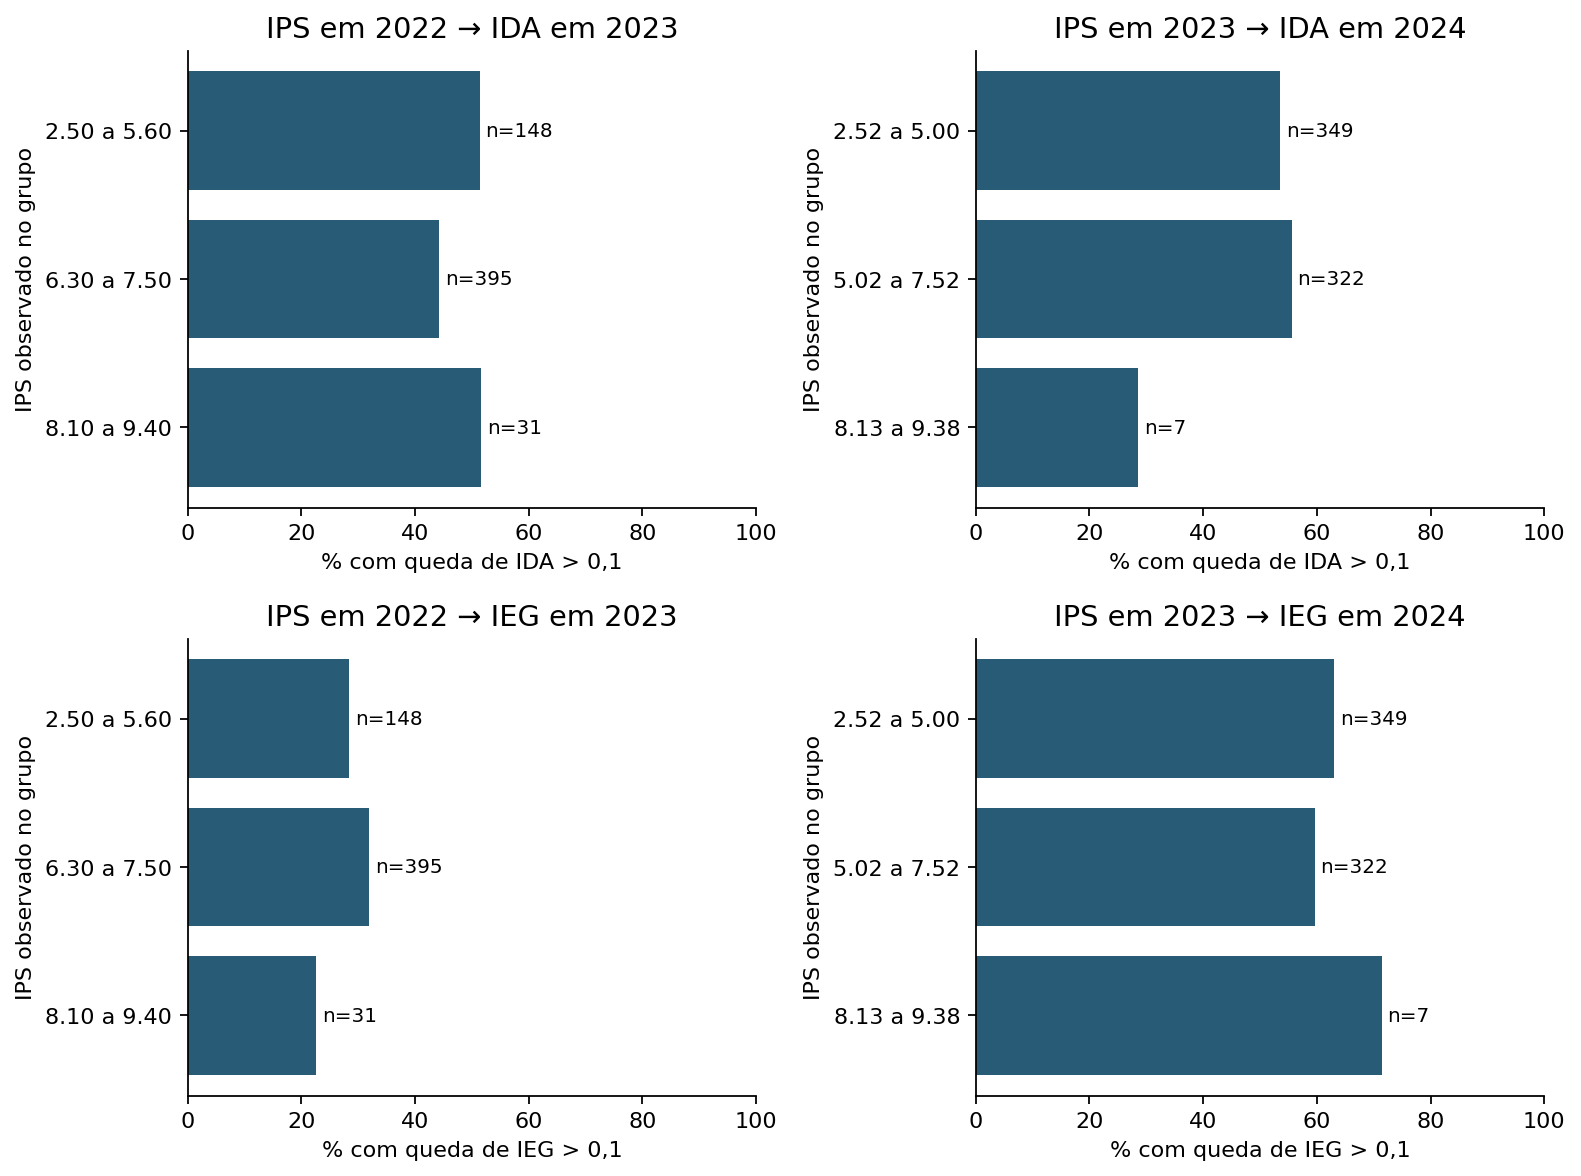

**Como ler:** Cada barra mostra a parcela de alunos que perdeu mais de 0,1 ponto no ano seguinte. n indica o tamanho do grupo inicial com as duas avaliações.

In [12]:
q5_rows=[];q5_bands=[]
for ano,g in PARES_ESCOLARES.groupby('ano_inicio'):
    for destino in ['ida','ieg']:
        z=g[['ra','ips_inicio',destino+'_inicio',destino+'_fim','delta_'+destino]].dropna().copy()
        q5_rows.append({'origem':ano,'desfecho':f'delta_{destino}',**rho(z,'ips_inicio','delta_'+destino),
            'quedas_maiores_01':int(z['delta_'+destino].lt(-.1-1e-9).sum()),
            'pct_queda_01':100*z['delta_'+destino].lt(-.1-1e-9).mean(),
            'pct_qualquer_queda':100*z['delta_'+destino].lt(-1e-9).mean()})
        z['faixa_ips']=pd.qcut(z.ips_inicio,4,duplicates='drop')
        for faixa,h in z.groupby('faixa_ips',observed=True):
            q5_bands.append({'origem':ano,'desfecho':destino,'faixa_ips':str(faixa),'ips_min':h.ips_inicio.min(),'ips_max':h.ips_inicio.max(),'n':len(h),
                'quedas':int(h['delta_'+destino].lt(-.1-1e-9).sum()),'pct_queda':100*h['delta_'+destino].lt(-.1-1e-9).mean()})
q5=tabela(pd.DataFrame(q5_rows),'q5_ips_antecedencia')
q5_bands=tabela(pd.DataFrame(q5_bands),'q5_faixas_ips')
fig,axes=plt.subplots(2,2,figsize=(10,7.5))
for ax,(ano,destino) in zip(axes.flat,[(2022,'ida'),(2023,'ida'),(2022,'ieg'),(2023,'ieg')]):
    z=q5_bands[(q5_bands.origem==ano)&(q5_bands.desfecho==destino)]
    rotulos=[f'{a:.2f} a {b:.2f}' for a,b in zip(z.ips_min,z.ips_max)]
    ax.barh(rotulos,z.pct_queda,color=CORES[0]);ax.invert_yaxis()
    for i,(_,r) in enumerate(z.iterrows()):ax.text(r.pct_queda+1,i,f'n={r.n}',va='center',fontsize=9)
    ax.set(xlim=(0,100),xlabel=f'% com queda de {destino.upper()} > 0,1',ylabel='IPS observado no grupo',title=f'IPS em {ano} → {destino.upper()} em {ano+1}')
figura(fig,'q5_ips_quedas','Cada barra mostra a parcela de alunos que perdeu mais de 0,1 ponto no ano seguinte. n indica o tamanho do grupo inicial com as duas avaliações.')

**Resposta:** Não apareceu um padrão consistente. A associação do IPS anterior com a mudança de IDA foi próxima de 0,03 nas duas transições; com a mudança de IEG, −0,02 e +0,03. Queda foi definida como redução superior a 0,1 ponto, também comparada com qualquer redução. O IPS isolado não sustenta um alerta antecipado nesta base. Isso não reduz a importância do apoio psicossocial; sua comparabilidade entre anos continua incerta.

### Pergunta 6
**Pergunta:** As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

**Gráfico:** Avaliação psicopedagógica por adequação: boxplots de IPP por grupo de defasagem em 2023 e 2024, com valores atípicos e tamanho dos grupos.

,ano,classe_defasagem,n,media,mediana,q25,q75
0,2023,Em fase,388,7.6652,7.8125,7.2917,8.2812
1,2023,Moderada,536,7.5048,7.5000,6.8750,8.1250
2,2023,Severa,14,6.9568,7.5781,6.4193,7.8906
3,2024,Em fase,520,7.6879,7.7083,7.2917,8.2500
4,2024,Moderada,531,7.4132,7.5000,6.8750,7.9167
5,2024,Severa,3,7.2604,7.0312,6.9531,7.4531


,ano,n,rho
0,2023,938,0.1058
1,2024,1054,0.1597


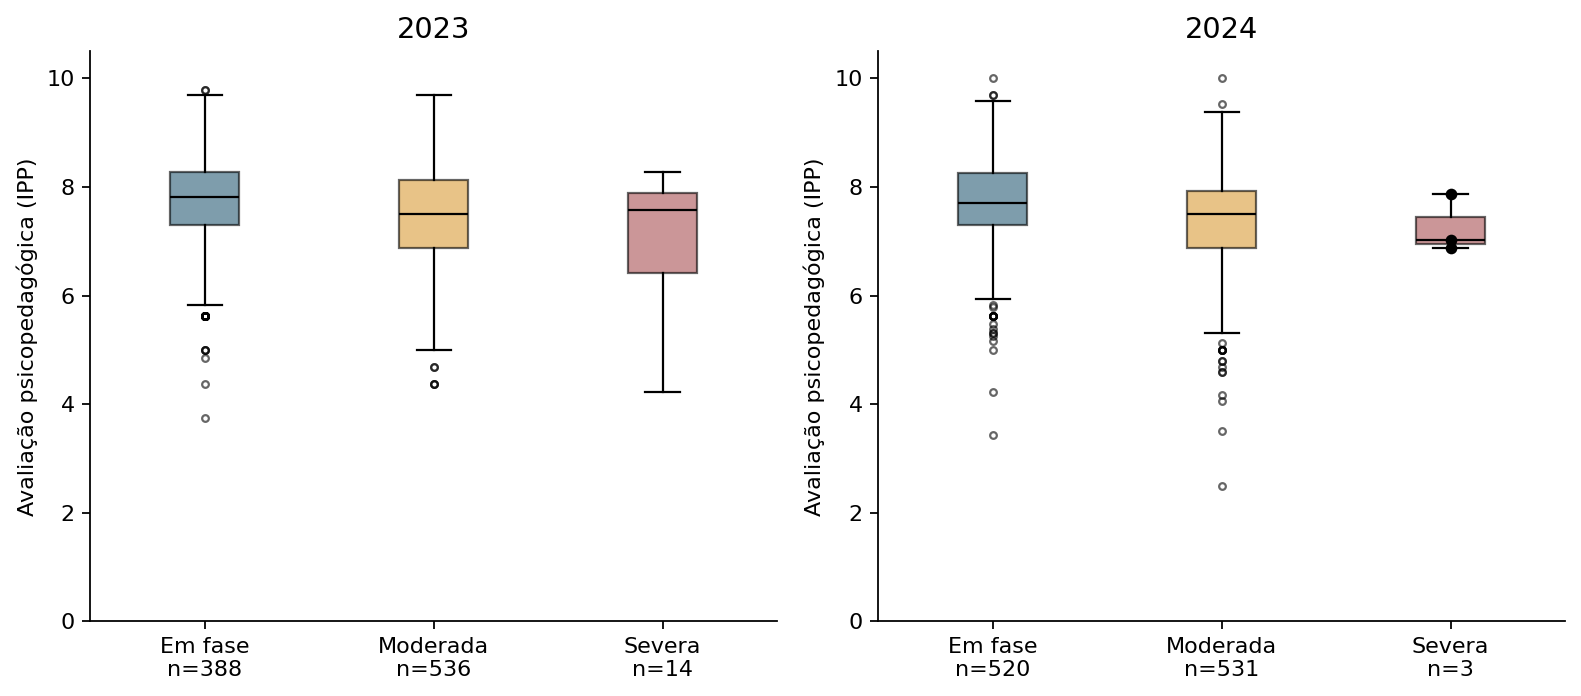

**Como ler:** A linha é a mediana; a caixa reúne os 50% centrais das notas. Pontos além das hastes são valores atípicos, não necessariamente erros. Nos grupos com menos de cinco alunos mostramos todas as notas; n é o tamanho do grupo.

In [13]:
q6_groups=ESCOLARES[ESCOLARES.ano.isin([2023,2024])].groupby(['ano','classe_defasagem']).ipp.agg(
    n='count',media='mean',mediana='median',q25=lambda s:s.quantile(.25),q75=lambda s:s.quantile(.75)).reset_index()
tabela(q6_groups,'q6_ipp_por_defasagem')
q6=tabela(pd.DataFrame([{'ano':ano,**rho(g,'ipp','ian')} for ano,g in ESCOLARES[ESCOLARES.ano.ge(2023)].groupby('ano')]),'q6_correlacao')
fig,axes=plt.subplots(1,2,figsize=(10,4.5))
for ax,ano in zip(axes,[2023,2024]):
    g=ESCOLARES[ESCOLARES.ano.eq(ano)]
    valores=[g.loc[g.classe_defasagem.eq(c),'ipp'].dropna().to_numpy() for c in CLASSES]
    boxes=ax.boxplot(valores,patch_artist=True,showfliers=True,whis=1.5,
        tick_labels=[f'{c}\nn={len(v)}' for c,v in zip(CLASSES,valores)],
        medianprops={'color':'black'},flierprops={'marker':'o','markersize':3,'alpha':.6})
    for box,cor in zip(boxes['boxes'],CORES):box.set_facecolor(cor);box.set_alpha(.6)
    for pos,notas in enumerate(valores,1):
        if len(notas)<5:ax.scatter(np.full(len(notas),pos),notas,color='black',s=18,zorder=3)
    ax.set(ylim=(0,10.5),ylabel='Avaliação psicopedagógica (IPP)',title=str(ano))
figura(fig,'q6_ipp_defasagem','A linha é a mediana; a caixa reúne os 50% centrais das notas. Pontos além das hastes são valores atípicos, não necessariamente erros. Nos grupos com menos de cinco alunos mostramos todas as notas; n é o tamanho do grupo.')

**Resposta:** Há concordância fraca no conjunto, sem confirmação individual: as correlações IPP–IAN são 0,11 e 0,16. A mediana de IPP dos alunos em fase foi 7,81 e 7,71; nos moderadamente defasados, 7,50 nos dois anos. Um aluno defasado pode ter boa avaliação psicopedagógica. Os indicadores se complementam. Não há IPP em 2022 e os grupos severos são pequenos.

### Pergunta 7
**Pergunta:** Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV ao longo do tempo?

**Gráfico:** Relações com o ponto de virada: associações no mesmo ano e entre indicadores anteriores e a mudança posterior de IPV.

,ano,indicador,n,rho
0,2022,IDA,860,0.6238
1,2022,IEG,860,0.5403
2,2022,IPS,860,0.1899
3,2022,IAA,860,0.2446
4,2022,IPP,0,NaN
5,2023,IDA,937,0.5513
6,2023,IEG,938,0.4920
7,2023,IPS,932,0.0725
8,2023,IAA,938,0.1553
9,2023,IPP,938,0.5124


,origem,indicador,relacao,n,rho
0,2022,IDA,Anterior × mudança de IPV,574,-0.1903
1,2022,IDA,Mudanças simultâneas,574,0.3174
2,2022,IEG,Anterior × mudança de IPV,574,-0.1324
3,2022,IEG,Mudanças simultâneas,574,0.2258
4,2022,IPS,Anterior × mudança de IPV,574,-0.0164
5,2022,IPS,Mudanças simultâneas,570,0.0645
6,2022,IAA,Anterior × mudança de IPV,574,-0.0555
7,2022,IAA,Mudanças simultâneas,574,0.0875
8,2022,IPP,Anterior × mudança de IPV,0,NaN
9,2022,IPP,Mudanças simultâneas,0,NaN


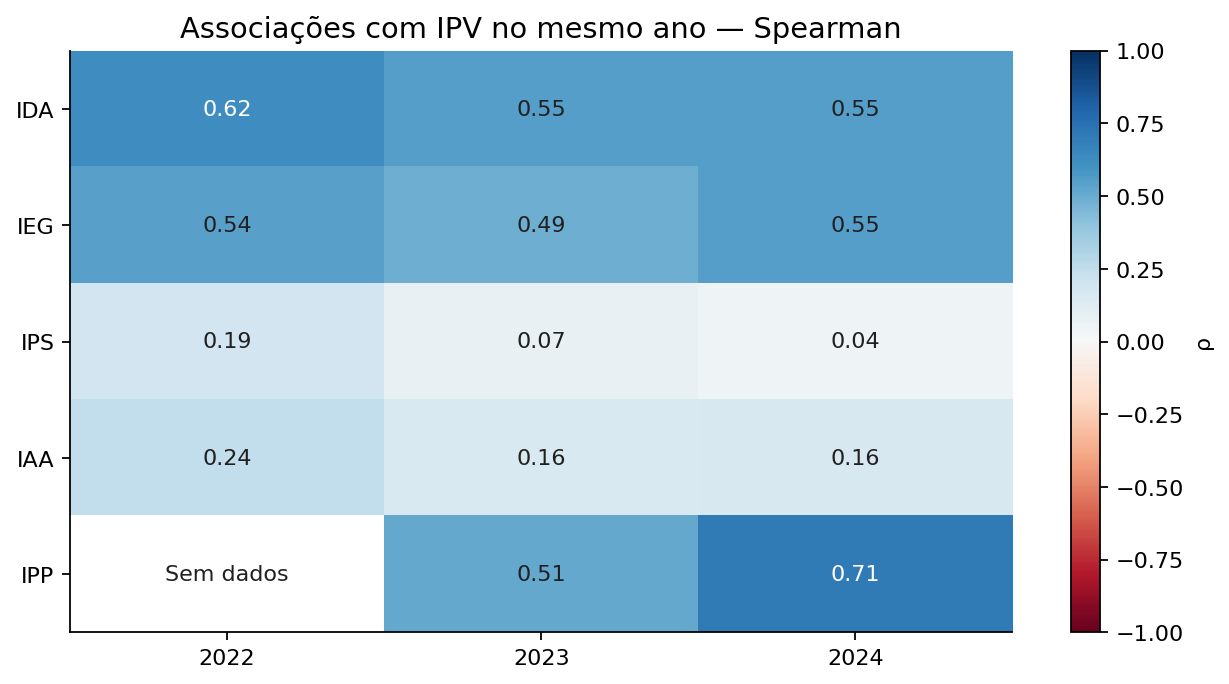

**Como ler:** Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.

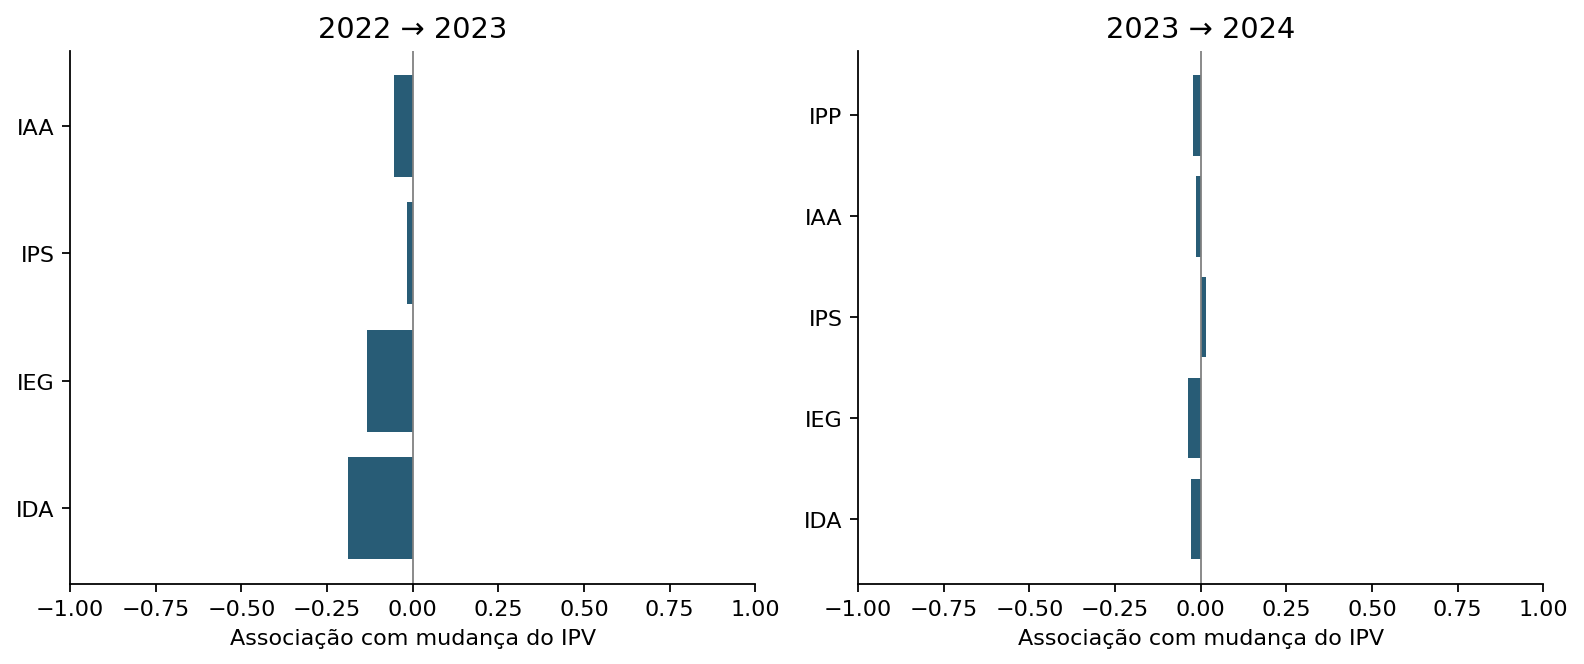

**Como ler:** Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.

In [14]:
q7_atual=[];q7_temporal=[]
for ano,g in ESCOLARES.groupby('ano'):
    for x in ['ida','ieg','ips','iaa','ipp']:
        q7_atual.append({'ano':ano,'indicador':x.upper(),**rho(g,x,'ipv')})
for ano,g in PARES_ESCOLARES.groupby('ano_inicio'):
    for x in ['ida','ieg','ips','iaa','ipp','ipv']:
        q7_temporal.append({'origem':ano,'indicador':x.upper(),'relacao':'Anterior × mudança de IPV',**rho(g,x+'_inicio','delta_ipv')})
        if x!='ipv':q7_temporal.append({'origem':ano,'indicador':x.upper(),'relacao':'Mudanças simultâneas',**rho(g,'delta_'+x,'delta_ipv')})
q7_atual=tabela(pd.DataFrame(q7_atual),'q7_associacoes_contemporaneas')
q7_temporal=tabela(pd.DataFrame(q7_temporal),'q7_associacoes_temporais')
ordem=['IDA','IEG','IPS','IAA','IPP']
fig,ax=plt.subplots(figsize=(8,4.4))
mat=q7_atual.pivot(index='indicador',columns='ano',values='rho').reindex(index=ordem,columns=ANOS)
im=ax.imshow(mat,vmin=-1,vmax=1,cmap='RdBu',aspect='auto')
for i in range(len(ordem)):
    for j in range(3):
        v=mat.iloc[i,j];ax.text(j,i,'Sem dados' if pd.isna(v) else f'{v:.2f}',ha='center',va='center',color='white' if pd.notna(v) and abs(v)>.6 else '#202020')
ax.set(xticks=range(3),xticklabels=ANOS,yticks=range(5),yticklabels=ordem,title='Associações com IPV no mesmo ano — Spearman')
fig.colorbar(im,ax=ax,label='ρ');figura(fig,'q7_associacoes_ipv','Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.')

fig,axes=plt.subplots(1,2,figsize=(10,4.3))
for ax,ano in zip(axes,[2022,2023]):
    g=q7_temporal[(q7_temporal.origem==ano)&(q7_temporal.relacao=='Anterior × mudança de IPV')&q7_temporal.indicador.ne('IPV')].dropna(subset=['rho'])
    ax.barh(g.indicador,g.rho,color=CORES[0]);ax.axvline(0,color='gray',linewidth=.8)
    ax.set(xlim=(-1,1),xlabel='Associação com mudança do IPV',title=f'{ano} → {ano+1}')
figura(fig,'q7_antecedencia','Valores positivos indicam avaliações que crescem juntas; negativos indicam direções opostas. Perto de zero há pouca associação. No segundo gráfico, a nota é anterior à mudança de IPV.')

**Resposta:** Em 2024, IPP teve a maior associação com IPV (0,71), seguido de IEG e IDA, próximos de 0,55. Mudanças de IDA acompanharam mudanças de IPV com correlações de 0,32 e 0,40; para IEG, 0,23 e 0,28. Porém, os indicadores anteriores não anteciparam a mudança de IPV de forma estável nas duas transições. Os dados apontam dimensões para acompanhar em conjunto, sem demonstrar influência causal.

### Pergunta 8
**Pergunta:** Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

**Gráfico:** Composição do INDE e perfis conjuntos: contribuição dos componentes e maiores médias por combinação, com pelo menos 20 alunos.

Perfis com maior INDE médio e n ≥ 20 por ano:


,ano,indicador,mediana
0,2023,IDA,6.8000
1,2023,IEG,9.0000
2,2023,IPS,5.0000
3,2023,IPP,7.6562
4,2024,IDA,6.7500
5,2024,IEG,8.5922
6,2024,IPS,7.5100
7,2024,IPP,7.5000


,ano,n,erro_absoluto_medio,erro_maximo
0,2023,931,0.0051,0.0149
1,2024,1054,0.0000,0.0000


,ano,indicador,peso,contribuicao_media
0,2023,IAN,0.1,0.7044
1,2023,IDA,0.2,1.3339
2,2023,IEG,0.2,1.7405
3,2023,IAA,0.1,0.6907
4,2023,IPS,0.1,0.5135
5,2023,IPP,0.1,0.7565
6,2023,IPV,0.2,1.6066
7,2024,IAN,0.1,0.7460
8,2024,IDA,0.2,1.2700
9,2024,IEG,0.2,1.6177


,ano,perfil,n,inde_medio,inde_mediano
1,2023,IDA alto | IEG alto | IPS alto | IPP baixo,79,8.252,8.285
0,2023,IDA alto | IEG alto | IPS alto | IPP alto,107,8.207,8.228
2,2023,IDA alto | IEG alto | IPS baixo | IPP alto,87,7.917,7.935
16,2024,IDA alto | IEG alto | IPS alto | IPP alto,193,8.404,8.397
18,2024,IDA alto | IEG alto | IPS baixo | IPP alto,128,8.320,8.279
17,2024,IDA alto | IEG alto | IPS alto | IPP baixo,26,7.892,7.896


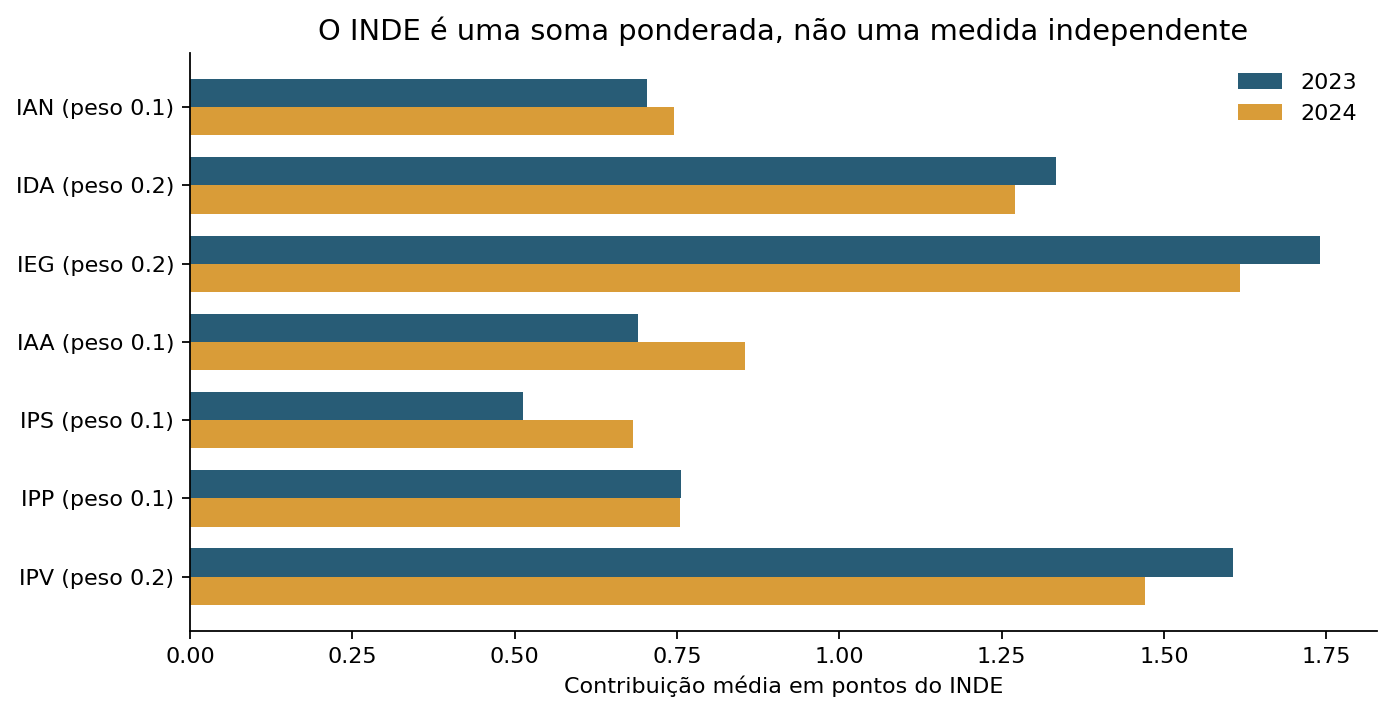

**Como ler:** O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.

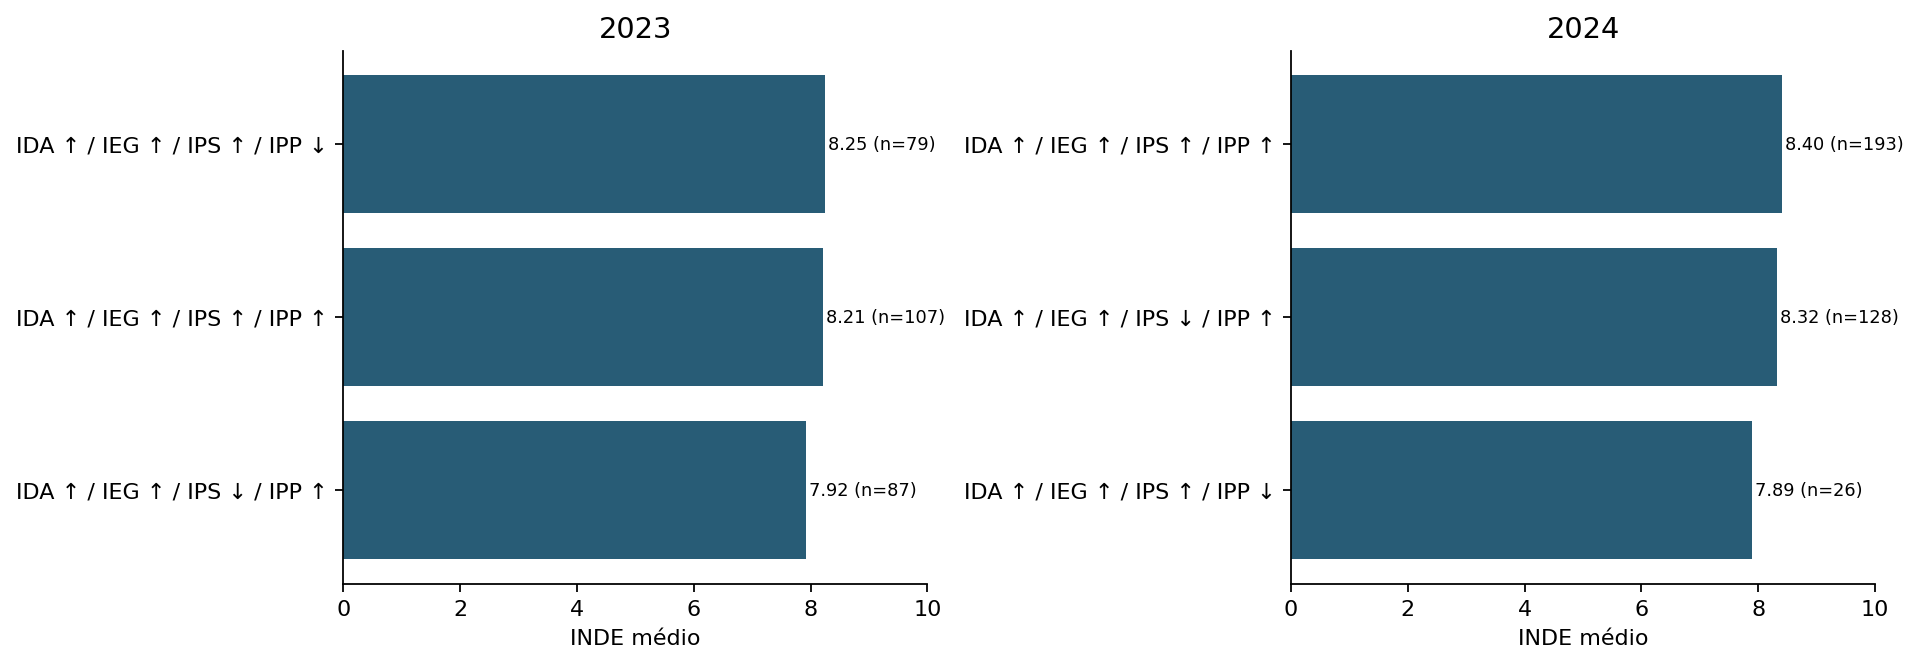

**Como ler:** O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.

In [15]:
PESOS={'ian':.1,'ida':.2,'ieg':.2,'iaa':.1,'ips':.1,'ipp':.1,'ipv':.2}
q8_perf=[];q8_lim=[];q8_contrib=[];q8_formula=[]
for ano in [2023,2024]:
    g=ESCOLARES[ESCOLARES.ano.eq(ano)].dropna(subset=list(PESOS)+['inde']).copy()
    calc=sum(g[c]*p for c,p in PESOS.items())
    q8_formula.append({'ano':ano,'n':len(g),'erro_absoluto_medio':(calc-g.inde).abs().mean(),'erro_maximo':(calc-g.inde).abs().max()})
    for c,peso in PESOS.items():q8_contrib.append({'ano':ano,'indicador':c.upper(),'peso':peso,'contribuicao_media':(g[c]*peso).mean()})
    chaves=['ida','ieg','ips','ipp'];limites=g[chaves].median()
    for c in chaves:q8_lim.append({'ano':ano,'indicador':c.upper(),'mediana':limites[c]})
    g['perfil']=g.apply(lambda r:' | '.join(f'{c.upper()} {"alto" if r[c]>=limites[c] else "baixo"}' for c in chaves),axis=1)
    for perfil,z in g.groupby('perfil'):
        q8_perf.append({'ano':ano,'perfil':perfil,'n':len(z),'inde_medio':z.inde.mean(),'inde_mediano':z.inde.median()})
q8_perfis=tabela(pd.DataFrame(q8_perf).sort_values(['ano','inde_medio'],ascending=[True,False]),'q8_perfis_completos',False)
tabela(pd.DataFrame(q8_lim),'q8_limites_perfis')
tabela(pd.DataFrame(q8_formula),'q8_validacao_formula')
q8_contrib=tabela(pd.DataFrame(q8_contrib),'q8_contribuicoes')
print('Perfis com maior INDE médio e n ≥ 20 por ano:')
display(q8_perfis[q8_perfis.n.ge(20)].groupby('ano').head(3).round(3))
fig,ax=plt.subplots(figsize=(8.8,4.6));ordem=list(PESOS);pos=np.arange(7)
for ano,deslocamento,cor in [(2023,-.18,CORES[0]),(2024,.18,CORES[1])]:
    g=q8_contrib[q8_contrib.ano.eq(ano)].set_index('indicador').reindex([c.upper() for c in ordem])
    ax.barh(pos+deslocamento,g.contribuicao_media,height=.36,label=str(ano),color=cor)
ax.set(yticks=pos,yticklabels=[f'{c.upper()} (peso {PESOS[c]:.1f})' for c in ordem],xlabel='Contribuição média em pontos do INDE',title='O INDE é uma soma ponderada, não uma medida independente')
ax.invert_yaxis();ax.legend(frameon=False);figura(fig,'q8_composicao_inde','O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.')

fig,axes=plt.subplots(1,2,figsize=(12,4.3))
for ax,ano in zip(axes,[2023,2024]):
    g=q8_perfis[q8_perfis.ano.eq(ano)&q8_perfis.n.ge(20)].head(3)
    rotulos=g.perfil.str.replace(' | ',' / ',regex=False).str.replace('alto','↑').str.replace('baixo','↓')
    ax.barh(rotulos,g.inde_medio,color=CORES[0]);ax.invert_yaxis()
    for i,r in enumerate(g.itertuples()): ax.text(r.inde_medio+.05,i,f'{r.inde_medio:.2f} (n={r.n})',va='center',fontsize=8)
    ax.set(xlim=(0,10),xlabel='INDE médio',title=str(ano))
figura(fig,'q8_perfis','O primeiro gráfico mostra parcelas da nota global. No segundo, alto significa igual ou acima da mediana anual, baixo significa abaixo. As médias não isolam efeitos de intervenções.')

**Resposta:** IDA e IEG têm peso de 20% cada; IPS e IPP, 10% cada. Pela fórmula, aumentar um ponto nos quatro acrescenta 0,6 ao INDE, mantendo os demais componentes fixos. Em 2024, o perfil com os quatro indicadores na mediana ou acima teve média 8,40 (193 alunos). Em 2023, a maior média entre perfis com pelo menos 20 alunos foi 8,25: IDA/IEG/IPS altos e IPP baixo (79 alunos). Os outros componentes também variam, portanto esse resultado não indica benefício em reduzir IPP.

## 4. Previsão de novos casos
**Entradas:** IDA, IEG, IPV e fase. A fase foi convertida em número, os anos ligados por RA e o alvo calculado na avaliação seguinte. A padronização é ajustada apenas no treino de cada divisão. Não há preenchimento de entradas ausentes nessas coortes.

IPS foi retirado após revisão de comparabilidade; idade, por correlação de 0,972 com fase. IPP não existe em 2022, IAA tem zeros ambíguos e INDE já combina dimensões. Isso não prova que as quatro entradas sejam as melhores possíveis. A disponibilidade de IPV no momento da previsão ainda precisa ser confirmada para uso real.

**Histórico da validação:** o primeiro modelo usava seis entradas e corte de 33,4%; teve 24 casos identificados, 10 falsos alertas, AP 0,614 e recall 28,6%. A versão atual surgiu após examinar esse resultado. Preservamos essa referência nos metadados, sem reapresentar 2024 como teste independente.

### Pergunta 9
**Pergunta:** Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

**Gráfico:** Resultados da previsão: matriz de acertos e erros no corte de 27,8%, curva de precisão e identificação de casos e pesos do modelo.

#### Comparação dos modelos
Reproduzimos somente as três configurações já avaliadas, com as mesmas quatro entradas e cinco divisões do desenvolvimento. A AP média compara a priorização dos casos; a diferença treino–validação ajuda a avaliar sobreajuste.

O critério registrado na revisão anterior exigia superar a Logística em 0,02 de AP média e em pelo menos três divisões, com diferença treino–validação até 0,10 e Brier até 0,01 acima da Logística. São tolerâncias práticas, não testes de significância. Esta execução reproduz a comparação; não é um novo experimento.

In [16]:
import sklearn
import scipy
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                            confusion_matrix, precision_recall_curve)
if sklearn.__version__ != '1.6.1':
    raise RuntimeError('Instale requirements.txt e reinicie a sessão antes de executar.')

FEATURES = ['ida','ieg','ipv','fase']
dev = coortes[2022]
X, y_dev = dev[FEATURES], dev.alvo.to_numpy()
particoes = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X,y_dev))
modelos = {
    'Logística': Pipeline([('escala',StandardScaler()),('modelo',LogisticRegression(C=1,solver='lbfgs',max_iter=2000,random_state=42))]),
    'Árvore': DecisionTreeClassifier(max_depth=2,min_samples_leaf=10,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300,max_depth=3,min_samples_leaf=10,max_features='sqrt',random_state=42,n_jobs=1)
}
resultados, detalhes, pesos_particoes, previsoes_oof = [], [], [], {}
for nome, modelo in modelos.items():
    previsoes = np.zeros(len(dev))
    ap_treino, ap_validacao = [], []
    for fold,(treino,validacao) in enumerate(particoes,1):
        ajuste = clone(modelo).fit(X.iloc[treino],y_dev[treino])
        previsoes[validacao] = ajuste.predict_proba(X.iloc[validacao])[:,1]
        ap_treino.append(average_precision_score(y_dev[treino],ajuste.predict_proba(X.iloc[treino])[:,1]))
        ap_validacao.append(average_precision_score(y_dev[validacao],previsoes[validacao]))
        detalhes.append(dict(modelo=nome,fold=fold,ap_treino=ap_treino[-1],ap_validacao=ap_validacao[-1]))
        if nome == 'Logística': pesos_particoes.append(ajuste.named_steps['modelo'].coef_[0])
    previsoes_oof[nome] = previsoes
    resultados.append(dict(modelo=nome,ap_media=float(np.mean(ap_validacao)),ap_dp=float(np.std(ap_validacao,ddof=1)),
        gap_ap=float(np.mean(ap_treino)-np.mean(ap_validacao)),ap_oof=average_precision_score(y_dev,previsoes),
        roc_auc_oof=roc_auc_score(y_dev,previsoes),brier_oof=brier_score_loss(y_dev,previsoes)))
comparacao = pd.DataFrame(resultados)
folds = pd.DataFrame(detalhes)
referencia = comparacao.set_index('modelo').loc['Logística']
ap_por_fold = folds.pivot(index='fold',columns='modelo',values='ap_validacao')
comparacao['folds_superiores'] = comparacao.modelo.map(lambda n:int((ap_por_fold[n]>ap_por_fold['Logística']).sum()))
comparacao['atende_criterio'] = (comparacao.modelo.ne('Logística') &
    comparacao.ap_media.ge(referencia.ap_media+.02) & comparacao.folds_superiores.ge(3) &
    comparacao.brier_oof.le(referencia.brier_oof+.01) & comparacao.gap_ap.le(.10))
display(comparacao[['modelo','ap_media','ap_dp','gap_ap','brier_oof']].rename(columns={
    'modelo':'Modelo','ap_media':'AP média nas 5 divisões','ap_dp':'Variação entre divisões',
    'gap_ap':'Diferença de AP treino–validação','brier_oof':'Erro das probabilidades (Brier)'}).round(3))
baseline_ap = float(np.mean([y_dev[va].mean() for _,va in particoes]))
print(f'Referência sem discriminação: AP média = {baseline_ap:.3f}')

Referência sem discriminação: AP média = 0.323


,Modelo,AP média nas 5 divisões,Variação entre divisões,Diferença de AP treino–validação,Erro das probabilidades (Brier)
0,Logística,0.639,0.084,-0.001,0.177
1,Árvore,0.522,0.044,0.074,0.185
2,Random Forest,0.583,0.123,0.170,0.181


A Logística teve AP média de **0,639**, contra **0,583** da Random Forest e **0,522** da árvore. Nenhuma alternativa cumpriu o critério de substituição. A floresta apresentou diferença de 0,170 entre treino e validação, sinal de maior sobreajuste.

**AP (Average Precision)** resume a precisão conforme ampliamos a parcela de casos identificados. “AP média” é a média desse resultado nas cinco divisões. A referência sem discriminação ficou em **0,323**, próxima da proporção de casos. O resultado de 0,639 é favorável e quase duas vezes essa referência; não equivale a 63,9% de acurácia, não mede calibração e não garante desempenho futuro. A AP das previsões reunidas das cinco divisões é 0,588, uma agregação diferente.

#### Corte de 27,8% e avaliação temporal
O corte define quando a probabilidade gera alerta; não altera a probabilidade. Adotamos **0,278 exato**, por decisão de priorizar revisões mais assertivas após conhecer os resultados anteriores. O corte histórico de 0,2778104299 gera as mesmas classificações nesta amostra. Não houve nova busca de cortes em 2024.

,Corte,Alunos sinalizados,Casos identificados,Falsos alertas,Casos sem alerta,Proporção de alertas confirmados,Proporção de casos identificados
0,"21,7% (anterior)",111,58,53,26,0.523,0.690
1,"27,8% (adotado)",69,44,25,40,0.638,0.524


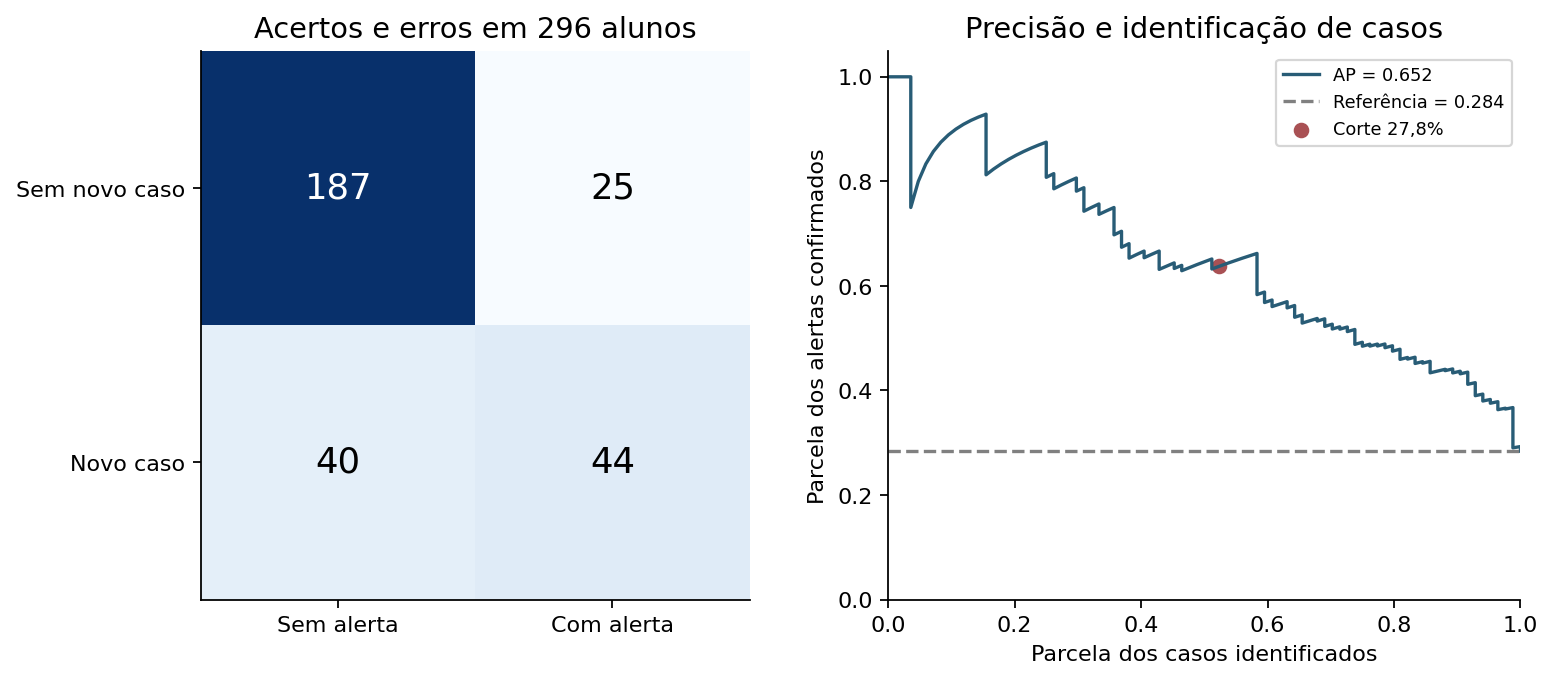

**Como ler:** A matriz cruza o que aconteceu com o alerta emitido. Na curva, avançar à direita identifica mais casos; a altura mostra quanto dos alertas se confirma.

,Métrica,Resultado
0,Acurácia,0.780
1,Equilíbrio entre precisão e recall (F1),0.575
2,Average Precision,0.652
3,Área sob a curva ROC,0.813
4,Erro das probabilidades (Brier),0.160
5,Probabilidade média,0.210
6,Proporção observada de casos,0.284


In [17]:
def medir(y_real, probabilidade, corte):
    tn,fp,fn,tp = confusion_matrix(y_real,probabilidade>=corte,labels=[0,1]).ravel()
    return dict(n=len(y_real),positivos=int(np.sum(y_real)),tp=int(tp),fp=int(fp),fn=int(fn),tn=int(tn),
        alertas=int(tp+fp),precisao=float(tp/(tp+fp)) if tp+fp else 0.,recall=float(tp/(tp+fn)),
        f1=float(2*tp/(2*tp+fp+fn)),acuracia=float((tp+tn)/len(y_real)),
        ap=average_precision_score(y_real,probabilidade),roc_auc=roc_auc_score(y_real,probabilidade),
        brier=brier_score_loss(y_real,probabilidade),prob_media=float(probabilidade.mean()))

CORTE = 0.278
CORTE_ANTERIOR = 0.21685686133388166
modelo_final = clone(modelos['Logística']).fit(X,y_dev)
teste = coortes[2023]
yt = teste.alvo.to_numpy()
probabilidades = modelo_final.predict_proba(teste[FEATURES])[:,1]
metricas = medir(yt,probabilidades,CORTE)
metricas_anteriores = medir(yt,probabilidades,CORTE_ANTERIOR)
tradeoff = pd.DataFrame([{'Corte':'21,7% (anterior)',**metricas_anteriores},{'Corte':'27,8% (adotado)',**metricas}])
display(tradeoff[['Corte','alertas','tp','fp','fn','precisao','recall']].rename(columns={
    'alertas':'Alunos sinalizados','tp':'Casos identificados','fp':'Falsos alertas','fn':'Casos sem alerta',
    'precisao':'Proporção de alertas confirmados','recall':'Proporção de casos identificados'}).round(3))
assert (metricas['tp'],metricas['fp'],metricas['fn'],metricas['tn']) == (44,25,40,187)
assert np.array_equal(probabilidades>=CORTE,probabilidades>=0.2778104298913131)

fig,axes=plt.subplots(1,2,figsize=(10,4.4))
matriz=confusion_matrix(yt,probabilidades>=CORTE,labels=[0,1])
axes[0].imshow(matriz,cmap='Blues')
for (i,j),valor in np.ndenumerate(matriz):
    axes[0].text(j,i,str(valor),ha='center',va='center',color='white' if valor>matriz.max()/2 else 'black',fontsize=16)
axes[0].set(xticks=[0,1],yticks=[0,1],xticklabels=['Sem alerta','Com alerta'],yticklabels=['Sem novo caso','Novo caso'],title='Acertos e erros em 296 alunos')
precisao,recall,_=precision_recall_curve(yt,probabilidades)
axes[1].plot(recall,precisao,color=CORES[0],label=f'AP = {metricas["ap"]:.3f}')
axes[1].axhline(yt.mean(),linestyle='--',color='gray',label=f'Referência = {yt.mean():.3f}')
axes[1].scatter([metricas['recall']],[metricas['precisao']],color=CORES[2],label='Corte 27,8%')
axes[1].set(xlim=(0,1),ylim=(0,1.05),xlabel='Parcela dos casos identificados',ylabel='Parcela dos alertas confirmados',title='Precisão e identificação de casos')
axes[1].legend(fontsize=8)
figura(fig,'q9_resultados','A matriz cruza o que aconteceu com o alerta emitido. Na curva, avançar à direita identifica mais casos; a altura mostra quanto dos alertas se confirma.')
display(pd.DataFrame({'Métrica':['Acurácia','Equilíbrio entre precisão e recall (F1)','Average Precision','Área sob a curva ROC','Erro das probabilidades (Brier)','Probabilidade média','Proporção observada de casos'],
    'Resultado':[metricas[k] for k in ['acuracia','f1','ap','roc_auc','brier','prob_media']]+[float(yt.mean())]}).round(3))

Com o corte de 27,8%, **44 de 69 alertas se confirmaram (63,8%)**. São 42 revisões e 28 falsos alertas a menos que antes, mas também 14 casos identificados a menos. A identificação caiu de 69,0% para **52,4%**: **40 dos 84 casos não recebem alerta**. É uma escolha de prioridade, não uma melhora em todas as métricas nem evidência de economia financeira medida.

As probabilidades médias ficaram em 21,0%, abaixo dos 28,4% observados. O corte não corrige essa subestimação. Mantêm-se amostra pequena, perdas de acompanhamento e ausência de nova avaliação independente.

#### Como os indicadores afetam a previsão
Os pesos abaixo mostram associações condicionais: cada entrada varia mantendo as demais iguais. Não são efeitos de intervenções nem porcentagens de importância.

,Indicador,Peso padronizado,Peso por ponto
0,ida,-0.284,-0.185
1,ieg,0.386,0.349
2,ipv,-0.965,-1.101
3,fase,-0.768,-0.460


,ida,ieg,ipv,fase
min,-0.344,0.206,-1.058,-0.905
max,-0.212,0.516,-0.746,-0.684


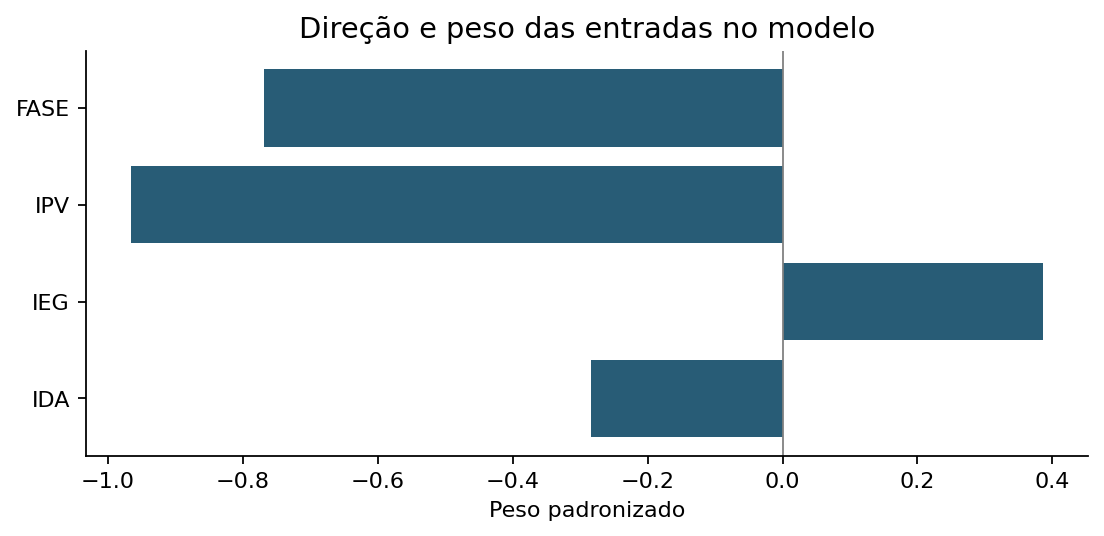

**Como ler:** À direita, a entrada eleva o escore de risco; à esquerda, reduz. A padronização permite comparar magnitudes, mantendo as demais entradas constantes.

,ida,ieg,ipv,fase,Probabilidade (%)
0,6.5,1.00,6.8,0,14.399
1,6.5,9.75,6.8,0,78.055
2,9.9,9.70,6.5,4,29.204


In [18]:
escala = modelo_final.named_steps['escala']
regressao = modelo_final.named_steps['modelo']
coeficientes = pd.DataFrame({'Indicador':FEATURES,'Peso padronizado':regressao.coef_[0],
    'Peso por ponto':regressao.coef_[0]/escala.scale_})
display(coeficientes.round(3))
display(pd.DataFrame(pesos_particoes,columns=FEATURES).agg(['min','max']).round(3))
fig,ax=plt.subplots(figsize=(7,3.5))
ax.barh(coeficientes.Indicador.str.upper(),coeficientes['Peso padronizado'],color=CORES[0])
ax.axvline(0,color='gray',linewidth=.8)
ax.set(xlabel='Peso padronizado',title='Direção e peso das entradas no modelo')
figura(fig,'q9_pesos','À direita, a entrada eleva o escore de risco; à esquerda, reduz. A padronização permite comparar magnitudes, mantendo as demais entradas constantes.')
exemplos = pd.DataFrame([[6.5,1.,6.8,0],[6.5,9.75,6.8,0],[9.9,9.7,6.5,4]],columns=FEATURES)
exemplos['Probabilidade (%)'] = 100*modelo_final.predict_proba(exemplos[FEATURES])[:,1]
display(exemplos.round(3))

**Exemplo A:** com IDA 6,5, IPV 6,8 e fase 0, o modelo reproduz **14,4% com IEG 1,0** e **78,1% com IEG 9,75**. O IEG tem peso positivo neste ajuste. A associação entre engajamento e risco futuro, condicionada às demais entradas, é diferente da correlação entre engajamento e notas no mesmo ano. A amostra e as relações entre variáveis podem contribuir para esse sinal; não comprovamos sua causa. IEG 1,0 está fora da faixa de treino, que começou em 4,6, portanto o primeiro resultado é extrapolação.

**Exemplo B:** fase 4, IDA 9,9, IEG 9,7 e IPV 6,5 produzem **29,2%**. Uma nota alta de IDA não anula as outras entradas. Na mesma escala de notas, um ponto de IPV altera o escore cerca de seis vezes mais que um ponto de IDA, em magnitude; a conversão para probabilidade é não linear. Os valores iniciais de IEG e IPV do resultado de 3,3% não foram informados, então não podemos separar quanto cada mudança contribuiu nesse exemplo.

O sinal positivo do IEG aparece nas cinco divisões internas, mas essa repetição no mesmo período não comprova estabilidade em novos anos. Não se deve recomendar reduzir engajamento com base no modelo.

**Resposta:** O modelo combina IDA, IEG, IPV e fase para prever entrada em defasagem no ano seguinte entre alunos inicialmente sem defasagem, nas fases 0–6. IPV e fase têm os maiores pesos padronizados, ambos negativos; IEG tem peso positivo neste ajuste, sem interpretação causal. No período posterior, o corte de 27,8% sinalizou 69 de 296 alunos: 44 casos confirmados e 25 falsos alertas. A precisão foi 63,8% e a identificação dos 84 casos foi 52,4%; 40 casos ficaram sem alerta. A proposta prioriza revisões mais assertivas, mantendo acompanhamento para todos. O resultado é exploratório, pois 2024 já havia sido examinado, e as probabilidades ainda subestimam o risco médio.

### Pergunta 10
**Pergunta:** Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

**Gráfico:** Evolução dos mesmos alunos: médias dos indicadores e mudança de IDA por pedra inicial de 2022.

,indicador,ano,n,media,mediana
0,DEFASAGEM,2022,441,-0.8322,-1.0000
1,DEFASAGEM,2023,441,-0.6848,-1.0000
2,DEFASAGEM,2024,441,-0.2426,0.0000
3,IDA,2022,435,6.6784,7.0000
4,IDA,2023,435,6.7687,6.8000
5,IDA,2024,435,6.2074,6.5000
6,IEG,2022,435,8.5251,8.8000
7,IEG,2023,435,8.7322,9.0000
8,IEG,2024,435,7.9488,8.3810
9,IPV,2022,435,7.5153,7.5000


,indicador,n,tolerancia,delta_medio,melhora,estavel,piora
0,DEFASAGEM,441,0.0,0.5896,251,142,48
1,IDA,435,0.0,-0.4710,191,4,240
2,IDA,435,0.1,-0.4710,181,21,233
3,IEG,435,0.0,-0.5762,186,9,240
4,IEG,435,0.1,-0.5762,170,39,226
5,IPV,435,0.0,-0.2204,185,2,248
6,IPV,435,0.1,-0.2204,171,35,229
7,INDE,434,0.0,-0.0025,240,0,194
8,INDE,434,0.1,-0.0025,213,39,182


,indicador,pedra_2022,n,delta_medio,pct_melhora
0,DEFASAGEM,Quartzo,26,0.3077,42.3077
1,DEFASAGEM,Ágata,108,0.3889,47.2222
2,DEFASAGEM,Ametista,206,0.6845,62.6214
3,DEFASAGEM,Topázio,101,0.6832,59.4059
4,IDA,Quartzo,26,1.9109,88.4615
5,IDA,Ágata,108,-0.1907,45.3704
6,IDA,Ametista,204,-0.6953,38.2353
7,IDA,Topázio,97,-0.9500,31.9588
8,IEG,Quartzo,26,0.3320,61.5385
9,IEG,Ágata,108,-0.8404,36.1111


2024,pedra_2022,Quartzo,Ágata,Ametista,Topázio
0,Quartzo,8,11,7,0
1,Ágata,26,47,29,6
2,Ametista,16,39,74,77
3,Topázio,2,6,25,68


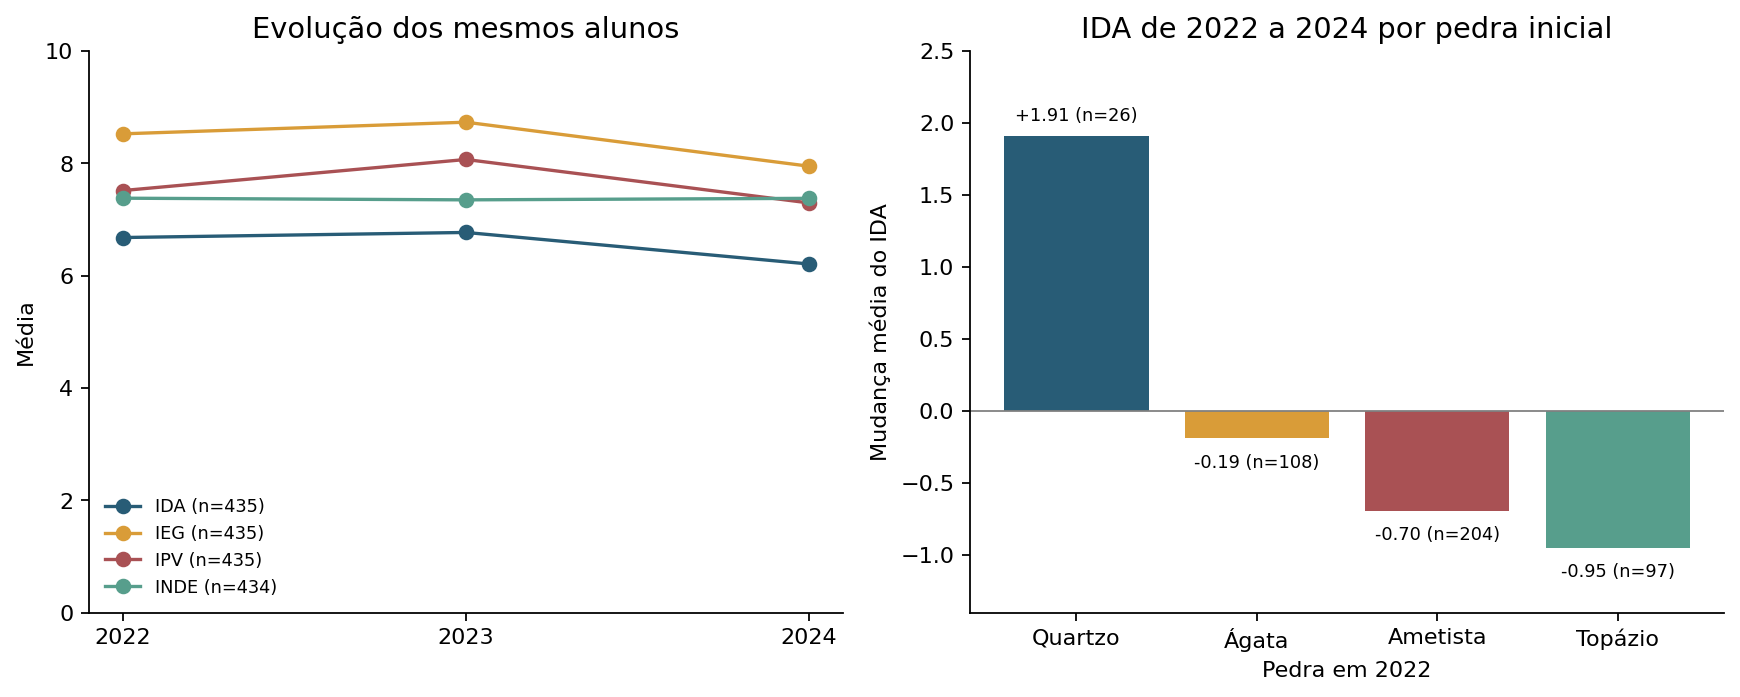

**Como ler:** As linhas acompanham os mesmos alunos com dados completos por indicador. As barras agrupam pela pedra de 2022; valores negativos indicam queda média de IDA até 2024.

In [19]:
q10_traj=[];q10_delta=[];q10_pedras=[]
pedra_inicio=PAINEL_ESCOLAR[PAINEL_ESCOLAR.ano.eq(2022)].set_index('ra').pedra
for indicador in ['defasagem','ida','ieg','ipv','inde']:
    w=painel_completo(indicador);delta=w[2024]-w[2022];tol=0 if indicador=='defasagem' else .1
    for ano in ANOS:q10_traj.append({'indicador':indicador.upper(),'ano':ano,'n':len(w),'media':w[ano].mean(),'mediana':w[ano].median()})
    for limiar in sorted(set([0,tol])):
        situacao=classe_delta(delta,limiar)
        q10_delta.append({'indicador':indicador.upper(),'n':len(w),'tolerancia':limiar,'delta_medio':delta.mean(),
            'melhora':int((situacao=='Melhora').sum()),'estavel':int((situacao=='Estável').sum()),'piora':int((situacao=='Piora').sum())})
    for pedra in PEDRAS:
        idx=delta.index.intersection(pedra_inicio[pedra_inicio.eq(pedra)].index);d=delta.loc[idx]
        q10_pedras.append({'indicador':indicador.upper(),'pedra_2022':pedra,'n':len(d),'delta_medio':d.mean(),
                           'pct_melhora':100*d.gt(tol+1e-9).mean() if len(d) else np.nan})
q10_traj=tabela(pd.DataFrame(q10_traj),'q10_trajetorias')
q10_delta=tabela(pd.DataFrame(q10_delta),'q10_mudancas_sensibilidade')
q10_pedras=tabela(pd.DataFrame(q10_pedras),'q10_mudanca_por_pedra_inicial')
pedras_w=PAINEL_ESCOLAR.pivot(index='ra',columns='ano',values='pedra')
pares_pedras=pedras_w[[2022,2024]].dropna()
mat_pedras=pd.crosstab(pares_pedras[2022],pares_pedras[2024]).reindex(index=PEDRAS,columns=PEDRAS,fill_value=0)
tabela(mat_pedras.reset_index().rename(columns={2022:'pedra_2022'}),'q10_transicao_pedras_22_24')
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for indicador,cor in [('IDA',CORES[0]),('IEG',CORES[1]),('IPV',CORES[2]),('INDE',CORES[3])]:
    g=q10_traj[q10_traj.indicador.eq(indicador)]
    axes[0].plot(g.ano,g.media,marker='o',color=cor,label=f'{indicador} (n={int(g.n.iloc[0])})')
axes[0].set(xticks=ANOS,ylim=(0,10),ylabel='Média',title='Evolução dos mesmos alunos')
axes[0].legend(frameon=False,fontsize=8,loc='lower left')
g=q10_pedras[q10_pedras.indicador.eq('IDA')].set_index('pedra_2022').reindex(PEDRAS)
axes[1].bar(PEDRAS,g.delta_medio,color=CORES[:4]);axes[1].axhline(0,color='gray',linewidth=.8)
axes[1].set(ylim=(-1.4,2.5),ylabel='Mudança média do IDA',xlabel='Pedra em 2022',title='IDA de 2022 a 2024 por pedra inicial')
for i,r in enumerate(g.itertuples()):
    axes[1].annotate(f'{r.delta_medio:+.2f} (n={r.n})',(i,r.delta_medio),xytext=(0,7 if r.delta_medio>=0 else -13),textcoords='offset points',ha='center',fontsize=8)
figura(fig,'q10_evolucao','As linhas acompanham os mesmos alunos com dados completos por indicador. As barras agrupam pela pedra de 2022; valores negativos indicam queda média de IDA até 2024.')

**Resposta:** A melhora não é uniforme. Dos 441 alunos acompanhados, 251 melhoraram a diferença de fases, 142 mantiveram e 48 pioraram. Entre 435 com IDA completo, 233 tiveram queda superior a 0,1 ponto. O INDE médio ficou próximo de 7,38 no início e no fim. Por pedra inicial, o IDA mudou +1,91 em Quartzo (26 alunos), −0,19 em Ágata (108), −0,70 em Ametista (204) e −0,95 em Topázio (97). Quartzo, Ágata, Ametista e Topázio são categorias de INDE, não fases escolares; seus cortes variam entre anos. Há evolução observada na adequação, mas, sem grupo de comparação, não é possível confirmar impacto causal do programa.

## 5. Verificações e exportação
Conferimos limites de escala, zeros, permanência e comparabilidade do IPS. Em 2022, 406 registros têm recomendação “Não atendido”, com IPS próximo de 7,5; a recomendação não foi preenchida nos anos seguintes. Os documentos não estabelecem equivalência das avaliações de 2023–2024.

In [20]:
sens_rows=[]
for ano,g in ESCOLARES.groupby('ano'):
    for x,y in [('ieg','ida'),('ieg','ipv'),('iaa','ida'),('iaa','ieg'),('ipp','ian')]:
        for modo in ['Observados','Escala estrita 0–10']:
            sens_rows.append({'ano':ano,'par':x.upper()+'–'+y.upper(),'analise':modo,**rho(g,x,y,estrito=modo!='Observados')})
sensibilidade=pd.DataFrame(sens_rows)
display(sensibilidade.pivot(index=['ano','par'],columns='analise',values='rho').round(3))
selecao=[]
for ano,g in ESCOLARES.groupby('ano'):
    for nome,z in [('Presente nos três anos',g[g.ra.isin(ids_tres_anos)]),('Demais observados',g[~g.ra.isin(ids_tres_anos)])]:
        selecao.append({'ano':ano,'grupo':nome,'n':len(z),'ida_n':z.ida.count(),'ida_media':z.ida.mean(),
                       'ieg_n':z.ieg.count(),'ieg_media':z.ieg.mean(),'pct_defasado':100*z.defasagem.lt(0).mean()})
tabela(pd.DataFrame(selecao),'comparacao_permanencia')
print('A sensibilidade está na tabela acima; não substitui silenciosamente a análise observada.')

resumos_ips=[]
for nome,base_analise in [('Base escolar anual',ESCOLARES),('Painel escolar fixo',PAINEL_ESCOLAR)]:
    for ano,g in base_analise.groupby('ano'):
        resumos_ips.append({'populacao':nome,'ano':ano,'n_validos':g.ips.count(),
            'media_ips':g.ips.mean(),'mediana_ips':g.ips.median(),'valores_distintos':g.ips.nunique()})
display(pd.DataFrame(resumos_ips).round(3))
for ano in ANOS:
    fonte=brutas[f'PEDE{ano}']
    print(ano,'recomendações psicológicas preenchidas:',int(fonte['Rec Psicologia'].notna().sum()))
resumo_recomendacao=brutas['PEDE2022'].groupby('Rec Psicologia').IPS.agg(['count','mean','min','max']).reset_index()
display(resumo_recomendacao.round(3))
# Revalidar os rótulos e D=fase−fase ideal nos registros que efetivamente entram no modelo.
for ano in [2022,2023]:
    ids=coortes[ano].ra
    inicial=alunos_ano[alunos_ano.ano.eq(ano)&alunos_ano.ra.isin(ids)].set_index('ra').loc[ids]
    final=alunos_ano[alunos_ano.ano.eq(ano+1)&alunos_ano.ra.isin(ids)].set_index('ra').loc[ids]
    assert inicial.defasagem.eq(inicial.fase-inicial.fase_ideal).all()
    assert final.defasagem.eq(final.fase-final.fase_ideal).all()
    assert np.array_equal(coortes[ano].alvo.to_numpy(),final.defasagem.lt(0).astype(int).to_numpy())
print('Alvos e elegibilidade conferidos: sem divergências nas duas coortes.')

A sensibilidade está na tabela acima; não substitui silenciosamente a análise observada.
2022 recomendações psicológicas preenchidas: 860
2023 recomendações psicológicas preenchidas: 0
2024 recomendações psicológicas preenchidas: 0
Alvos e elegibilidade conferidos: sem divergências nas duas coortes.


analise       Escala estrita 0–10  Observados
ano  par                                     
2022 IAA–IDA                0.183       0.183
     IAA–IEG                0.234       0.234
     IEG–IDA                0.507       0.507
     IEG–IPV                0.540       0.540
     IPP–IAN                  NaN         NaN
2023 IAA–IDA                0.127       0.127
     IAA–IEG                0.191       0.191
     IEG–IDA                0.446       0.446
     IEG–IPV                0.481       0.492
     IPP–IAN                0.106       0.106
2024 IAA–IDA                0.150       0.178
     IAA–IEG                0.228       0.230
     IEG–IDA                0.519       0.519
     IEG–IPV                0.551       0.551
     IPP–IAN                0.160       0.160

,ano,grupo,n,ida_n,ida_media,ieg_n,ieg_media,pct_defasado
0,2022,Presente nos três anos,468,468,6.6677,468,8.4910,67.3077
1,2022,Demais observados,392,392,5.4066,392,7.1750,72.9592
2,2023,Presente nos três anos,451,444,6.7752,444,8.7372,60.3104
3,2023,Demais observados,500,493,6.5627,494,8.6648,56.0000
4,2024,Presente nos três anos,441,441,6.2209,441,7.9721,36.9615
5,2024,Demais observados,613,613,6.4426,613,8.1725,60.5220


,populacao,ano,n_validos,media_ips,mediana_ips,valores_distintos
0,Base escolar anual,2022,860,6.905,7.500,12
1,Base escolar anual,2023,945,5.120,5.000,21
2,Base escolar anual,2024,1054,6.830,7.510,38
3,Painel escolar fixo,2022,441,6.886,7.500,10
4,Painel escolar fixo,2023,440,4.947,5.000,16
5,Painel escolar fixo,2024,441,6.692,6.885,34


,Rec Psicologia,count,mean,min,max
0,Não atendido,406,7.496,5.0,8.8
1,Não avaliado,5,7.500,7.5,7.5
2,Não indicado,37,5.086,3.8,7.5
3,Requer avaliação,158,5.529,2.5,8.8
4,Sem limitações,254,7.069,4.4,10.0


In [21]:
faixas = {nome:{'min':float(X[nome].min()),'max':float(X[nome].max())} for nome in FEATURES}
caminho_modelo = MODELS / 'modelo_risco.pkl'
with caminho_modelo.open('wb') as arquivo:
    pickle.dump(modelo_final,arquivo,protocol=4)

metadados = {
    'modelo':'StandardScaler + Regressão Logística C=1','features':FEATURES,'classe_positiva':1,
    'limiar':CORTE,'regra_uso':'predict_proba da classe 1 >= limiar',
    'populacao':'Sem defasagem atual, fases 0–6; desfecho observado no ano seguinte em fases 0–7',
    'desenvolvimento':{'origem':2022,'desfecho':2023,'alunos':186,'casos':60},
    'avaliacao_posterior':{'origem':2023,'desfecho':2024,'alunos':296,'casos':84},
    'nova_validacao_independente':False,'retreinado_com_periodo_posterior':False,'probabilidades_recalibradas':False,
    'faixas_treino':faixas,'sha256_modelo':hashlib.sha256(caminho_modelo.read_bytes()).hexdigest(),
    'versoes':{'python':platform.python_version(),'scikit_learn':sklearn.__version__,'numpy':np.__version__,
        'pandas':pd.__version__,'scipy':scipy.__version__},
    'hashes_dados':{nome:hashlib.sha256((DATA/nome).read_bytes()).hexdigest()
        for nome in ['base_pede.xlsx','alunos_ano.csv','desenvolvimento.csv','teste_temporal.csv']},
    'metricas_politica_adotada_exploratorias':metricas,
    'metricas_politica_anterior_exploratorias':metricas_anteriores,
    'metricas_politica_adotada_desenvolvimento_oof':medir(dev.alvo.to_numpy(),previsoes_oof['Logística'],CORTE),
    'politica_alerta_adotada':{'operador':'>=','corte_exato':CORTE,
        'origem':'27,8% exato solicitado após comparação anterior; sem nova otimização em 2024.',
        'corte_historico_arredondado':0.2778104298913131,'mesmas_classificacoes_nesta_amostra':True,
        'justificativa':'Priorizar alertas mais assertivos: 25 falsos alertas em vez de 53; 40 casos sem alerta em vez de 26.',
        'capacidade_associacao_confirmada':False},
    'comparacao_quatro_features':{'resultados':comparacao.to_dict('records'),'folds':detalhes,
        'baseline_ap_media':baseline_ap,'alternativas_avaliadas_em_2024':False,'artefato_substituido':False,
        'decisao':'Manter Logística; nenhuma alternativa atendeu ao critério registrado.',
        'protocolo_sha256':'841e3f059720340c26f340101333a591cef4320d24ed7df35c00ab6eee6fda92',
        'natureza':'Reprodução da comparação anterior; 5 divisões estratificadas, shuffle=True, random_state=42.',
        'criterio':'AP média >= Logística+0.02; superior em >=3/5 divisões; Brier <= Logística+0.01; gap AP <=0.10.'},
    'coeficientes':coeficientes.to_dict('records'),
    'limites':['Amostra pequena e perdas de acompanhamento.','Revisão após inspeção de 2024; avaliação exploratória.',
        'Probabilidades subestimadas.','Fase 6 pouco representada; IPV precisa estar disponível no momento da previsão.',
        'IEG tem sinal positivo condicional, sem interpretação causal.'],
    'historico':{'referencia_original_seis_features': {'n': 296,
                                       'positivos': 84,
                                       'ap': 0.6143724882089033,
                                       'roc_auc': 0.7918912848158132,
                                       'brier': 0.183504847290558,
                                       'recall': 0.2857142857142857,
                                       'precisao': 0.7058823529411765,
                                       'f1': 0.4067796610169492,
                                       'acuracia': 0.7635135135135135,
                                       'tp': 24,
                                       'fp': 10,
                                       'fn': 60,
                                       'tn': 202,
                                       'alertas': 34,
                                       'prob_media': 0.14172098154127222},
 'corte_original': 0.3343589429006473,
 'simplificacao': 'Após observar 2024, retirar IPS e idade por comparabilidade e redundância; seleção '
                  'interna com tolerâncias AP -0.03 e Brier +0.01.',
 'comparacao_simplificacoes': [{'modelo': 'referencia',
                                'n_features': 6,
                                'ap_media': 0.6602290839,
                                'brier': 0.1702725771,
                                'elegivel': True},
                               {'modelo': 'sem_ips',
                                'n_features': 5,
                                'ap_media': 0.6514542038,
                                'brier': 0.1747441063,
                                'elegivel': True},
                               {'modelo': 'sem_idade',
                                'n_features': 5,
                                'ap_media': 0.6223451376,
                                'brier': 0.1736152635,
                                'elegivel': False},
                               {'modelo': 'sem_ips_idade',
                                'n_features': 4,
                                'ap_media': 0.6389644136,
                                'brier': 0.177039001,
                                'elegivel': True}],
 'politicas_anteriores': {'35_8': {'n': 296,
                                   'positivos': 84,
                                   'ap': 0.6515162565255316,
                                   'roc_auc': 0.813230008984726,
                                   'brier': 0.16042328980215848,
                                   'recall': 0.36904761904761907,
                                   'precisao': 0.6739130434782609,
                                   'f1': 0.47692307692307695,
                                   'acuracia': 0.7702702702702703,
                                   'tp': 31,
                                   'fp': 15,
                                   'fn': 53,
                                   'tn': 197,
                                   'alertas': 46,
                                   'prob_media': 0.2097588101764007},
                          '21_7': {'n': 296,
                                   'positivos': 84,
                                   'ap': 0.6515162565255316,
                                   'roc_auc': 0.813230008984726,
                                   'brier': 0.16042328980215848,
                                   'recall': 0.6904761904761905,
                                   'precisao': 0.5225225225225225,
                                   'f1': 0.5948717948717949,
                                   'acuracia': 0.7331081081081081,
                                   'tp': 58,
                                   'fp': 53,
                                   'fn': 26,
                                   'tn': 159,
                                   'alertas': 111,
                                   'prob_media': 0.2097588101764007}}}
}
(MODELS/'metadados_modelo.json').write_text(json.dumps(metadados,ensure_ascii=False,indent=2),encoding='utf-8')
print('Exportados: três CSVs em data/, pipeline .pkl e metadados em models/.')
(OUTPUTS/'graficos_negocio.json').write_text(json.dumps(GRAFICOS_NEGOCIO,ensure_ascii=False),encoding='utf-8')
print('Gráficos das dez perguntas exportados para a aplicação.')


Exportados: três CSVs em data/, pipeline .pkl e metadados em models/.
Gráficos das dez perguntas exportados para a aplicação.


## Conclusão
A adequação de nível melhorou, mas o desempenho não avançou de forma contínua. Prioridades: investigar a queda de IDA em 2024, esclarecer zeros e ausências e acompanhar os indicadores em conjunto.

O modelo apoia a revisão de alunos sem defasagem atual. O corte de 27,8% prioriza a proporção de alertas confirmados, mantendo acompanhamento habitual também para quem não recebe alerta. A validação em novos anos continua necessária.

**Referências:** base PEDE, dicionário e pontos importantes em `data/`; [Associação Passos Mágicos](https://passosmagicos.org.br/); [Average Precision — scikit-learn](https://scikit-learn.org/1.6/modules/generated/sklearn.metrics.average_precision_score.html).